# EDA — Analisi esplorativa del dataset metabolomico longitudinale

**Studio InveCe** · Metabolomica FIBS + Microbiota · 4 timepoint (T1–T4, anni 0-2-4-8)

**Definizione frailty:** FI ≥ 0.25

**Struttura del notebook:**
1. Setup & caricamento dati
2. Dataset master
3. Qualità dei dati & floor effect
4. Descrizione della coorte
5. Definizione gruppi & transizioni
6. Confronto età tra gruppi
7. Floor per gruppo
8. RM-ANOVA per soggetti Never-frail
9. Univariata — gruppi (LMM + Mann-Whitney)
10. Univariata — FI continuo
11. Modelli predittivi — FI a T4
12. Riepilogo

---

In [31]:
# ── Imports ───────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (mannwhitneyu, spearmanr, f_oneway,
                          fisher_exact, friedmanchisquare)
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
import statsmodels.api as sm
import plotly.graph_objects as go
warnings.filterwarnings("ignore")

# ── Paths ──
FIBS_PATH   = "/Users/filipposaccomano/Library/CloudStorage/OneDrive-SharedLibraries-PolitecnicodiMilano/Riccardo Asnaghi - LongOMICS/Metabolomics data Mario Negri/FIBS_Single molecule_Feb26.xlsx"
MICRO_PATH  = "/Users/filipposaccomano/Library/CloudStorage/OneDrive-SharedLibraries-PolitecnicodiMilano/Riccardo Asnaghi - LongOMICS/Metabolomics data Mario Negri/Microbiota_Single molecule_Feb26.xlsx"
INVOKE_PATH = "/Users/filipposaccomano/Library/CloudStorage/OneDrive-SharedLibraries-PolitecnicodiMilano/Riccardo Asnaghi - LongOMICS/Metabolomics data Mario Negri/InveCe_Dataset_update2026.xlsx"

# ── Constants ──
TIMES         = [1, 2, 3, 4]
TIME_TO_YEARS = {1: 0, 2: 2, 3: 4, 4: 8}
FRAIL_THR     = 0.25          # FI >= 0.25 = frail
FLOOR_THR     = 40            # ⚙️ Soglia unica: solo metaboliti con % floor ≤ questo valore
SEED          = 42
OUTDIR        = "data"
BASELINE_YEAR = 2010
META_COLS     = ["HMDB_Metabolite", "Code", "Time", "FI", "Sesso", "BMI1",
                 "C_renale", "C_epatic10", "AnniScuo", "Subject"]

# ── Helpers ──
def fdr_bh(pvals):
    """FDR correction (Benjamini-Hochberg)."""
    pv = np.asarray(pvals, dtype=float)
    mask = np.isfinite(pv) & (pv >= 0) & (pv <= 1)
    q = np.full_like(pv, np.nan)
    if mask.sum() > 0:
        _, q[mask], _, _ = multipletests(pv[mask], method="fdr_bh")
    return q

def norm_code(x):
    """Normalizza codice paziente a stringa intera."""
    try:
        f = float(x)
        return str(int(f)) if f == int(f) else str(f)
    except (ValueError, TypeError):
        return str(x).strip()

np.random.seed(SEED)
os.makedirs(OUTDIR, exist_ok=True)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")
colors = {"Never-frail": "steelblue", "Ever-frail": "coral"}
print("✓ Setup OK")

✓ Setup OK


## A. Caricamento dati e merge

Caricamento dei tre dataset sorgenti:
- **FIBS**: metabolomica singola molecola (riga 0 = Feature ID, riga 1 = nomi)
- **Microbiota**: metabolomica singola molecola (header standard)
- **InveCe**: dataset demografico con `annonascita` (anno di nascita)

**Pipeline di merge:**
1. Carica FIBS e Microbiota, normalizza codici
2. Identifica e rimuove metaboliti duplicati tra i due dataset
3. Seleziona soggetti completi (T1–T4) presenti in entrambi
4. Merge inner su `(Code, Time)`
5. Aggiunge `annonascita` dal dataset InveCe

**Report:** pazienti mancanti in ogni dataset e feature ID duplicati.

In [32]:
# ── LOAD FIBS ─────────────────────────────────────────────────────────
raw_f = pd.read_excel(FIBS_PATH, sheet_name=0, header=None)
code_row = raw_f.iloc[0]
name_row = raw_f.iloc[1].astype(str)
data_f   = raw_f.iloc[2:].copy().reset_index(drop=True)
data_f.columns = name_row
meta_f = [c for c in META_COLS if c in data_f.columns]

rename_fibs = {}
fibs_code_to_name = {}
for j, col in enumerate(data_f.columns):
    if col in meta_f:
        continue
    c = code_row.iloc[j]
    if pd.isna(c):
        continue
    c_str = norm_code(c)
    rename_fibs[col] = c_str
    fibs_code_to_name[c_str] = str(col).strip()

df_fibs = data_f.rename(columns=rename_fibs).copy()
for c in ["Code", "Time", "FI"]:
    if c in df_fibs.columns:
        df_fibs[c] = pd.to_numeric(df_fibs[c], errors="coerce")
df_fibs = df_fibs.dropna(subset=["Code", "Time"]).copy()
df_fibs["Code"] = df_fibs["Code"].astype(int)
df_fibs["Time"] = df_fibs["Time"].astype(int)
df_fibs = df_fibs[df_fibs["Time"].isin(TIMES)].copy()
fibs_met = [c for c in df_fibs.columns if c not in meta_f]
print(f"FIBS: {df_fibs.shape}, {len(fibs_met)} metaboliti")

# ── LOAD MICROBIOTA ───────────────────────────────────────────────────
micro = pd.read_excel(MICRO_PATH, sheet_name=0, header=0)
micro.columns = [str(c).strip() for c in micro.columns]
micro = micro.rename(columns={"TIME": "Time", "time": "Time",
                               "ID Code": "Code", "CODE": "Code", "code": "Code"})
micro = micro.drop(columns=[c for c in ["ID"] if c in micro.columns], errors="ignore")
micro["Code"] = pd.to_numeric(micro["Code"], errors="coerce")
micro["Time"] = pd.to_numeric(micro["Time"], errors="coerce")
micro = micro.dropna(subset=["Code", "Time"]).copy()
micro["Code"] = micro["Code"].astype(int)
micro["Time"] = micro["Time"].astype(int)
micro = micro[micro["Time"].isin(TIMES)].copy()
micro_met = [c for c in micro.columns if c not in ["Code", "Time", "Subject"]]
micro = micro.rename(columns={c: norm_code(c) for c in micro_met})
micro_met = [c for c in micro.columns if c not in ["Code", "Time", "Subject"]]
micro[micro_met] = micro[micro_met].apply(pd.to_numeric, errors="coerce")
print(f"MICRO: {micro.shape}, {len(micro_met)} metaboliti")

# ── LOAD InveCe (annonascita) ─────────────────────────────────────────
raw_invoke = pd.read_excel(INVOKE_PATH, sheet_name="Foglio1", header=None)
invoke_headers = raw_invoke.iloc[1].values
invoke_data = raw_invoke.iloc[2:].copy()
invoke_data.columns = invoke_headers
invoke_df = invoke_data[["Code", "annonascita"]].copy()
invoke_df["Code"] = pd.to_numeric(invoke_df["Code"], errors="coerce")
invoke_df["annonascita"] = pd.to_numeric(invoke_df["annonascita"], errors="coerce")
invoke_df = invoke_df.dropna(subset=["Code"]).drop_duplicates(subset=["Code"])
invoke_df["Code"] = invoke_df["Code"].astype(int)
print(f"InveCe: {len(invoke_df)} pazienti con annonascita")

# ── REPORT: METABOLITI DUPLICATI ──────────────────────────────────────
dups = sorted(set(micro_met) & set(fibs_met))
print(f"\n{'='*60}")
print(f"METABOLITI DUPLICATI (FIBS ∩ MICRO): {len(dups)}")
print(f"{'='*60}")
for d in dups:
    name = fibs_code_to_name.get(d, "?")
    print(f"  Feature ID: {d}  →  Nome: {name}")
if dups:
    print(f"  → Rimossi da Microbiota (mantenuti da FIBS)")
    micro = micro.drop(columns=dups)
    micro_met = [c for c in micro.columns if c not in ["Code", "Time", "Subject"]]

# ── REPORT: PAZIENTI PER DATASET ─────────────────────────────────────
codes_fibs  = set(df_fibs["Code"].unique())
codes_micro = set(micro["Code"].unique())
codes_invoke = set(invoke_df["Code"].unique())

print(f"\n{'='*60}")
print(f"OVERLAP PAZIENTI")
print(f"{'='*60}")
print(f"  FIBS:    {len(codes_fibs)} pazienti unici")
print(f"  MICRO:   {len(codes_micro)} pazienti unici")
print(f"  InveCe:  {len(codes_invoke)} pazienti unici")

only_in_micro_not_fibs = sorted(codes_micro - codes_fibs)
only_in_fibs_not_micro = sorted(codes_fibs - codes_micro)
if only_in_micro_not_fibs:
    print(f"\n  Pazienti solo in MICRO (non in FIBS): {len(only_in_micro_not_fibs)}")
    print(f"    Codes: {only_in_micro_not_fibs}")
if only_in_fibs_not_micro:
    print(f"\n  Pazienti solo in FIBS (non in MICRO): {len(only_in_fibs_not_micro)}")
    print(f"    Codes: {only_in_fibs_not_micro}")

# ── SOGGETTI COMPLETI (T1-T4 in entrambi) ────────────────────────────
def complete_codes(df_):
    n = df_.groupby("Code")["Time"].nunique()
    return set(n[n == len(TIMES)].index.astype(int))

cc_fibs  = complete_codes(df_fibs[["Code", "Time"]])
cc_micro = complete_codes(micro[["Code", "Time"]])
common   = sorted(cc_fibs & cc_micro)
only_fibs = sorted(cc_fibs - cc_micro)
print(f"\nSoggetti completi (T1-T4) — FIBS: {len(cc_fibs)}, MICRO: {len(cc_micro)}, "
      f"Intersezione: {len(common)}")
if only_fibs:
    print(f"  Solo in FIBS (esclusi): {only_fibs}")

# Pazienti nel merge ma non in InveCe
in_merge_not_invoke = sorted(set(common) - codes_invoke)
if in_merge_not_invoke:
    print(f"\n  ⚠️ Pazienti nel merge ma NON in InveCe: {len(in_merge_not_invoke)}")
    print(f"    Codes: {in_merge_not_invoke}")
else:
    print(f"\n  ✓ Tutti i {len(common)} pazienti del merge sono presenti in InveCe")

# ── MERGE ─────────────────────────────────────────────────────────────
df = (df_fibs[df_fibs["Code"].isin(common)]
      .merge(micro[micro["Code"].isin(common)], on=["Code", "Time"], how="inner"))

# Aggiungi annonascita
df = df.merge(invoke_df, on="Code", how="left")
n_missing_anno = df["annonascita"].isna().sum()
if n_missing_anno > 0:
    print(f"  ⚠️ {n_missing_anno} righe senza annonascita")
else:
    print(f"  ✓ annonascita aggiunta per tutti i pazienti")

# ── QC ────────────────────────────────────────────────────────────────
n_pat = df["Code"].nunique()
n_expected = n_pat * len(TIMES)
assert len(df) == n_expected, f"Righe attese {n_expected}, trovate {len(df)}"
assert sorted(df["Time"].unique()) == TIMES
chk = df.groupby("Code")["Time"].apply(lambda s: sorted(s.unique()))
bad = chk[chk.apply(lambda t: t != TIMES)]
assert len(bad) == 0, f"{len(bad)} pazienti incompleti"
assert df.duplicated(subset=["Code", "Time"]).sum() == 0

print(f"\n✓ MERGE OK: {df.shape}")
print(f"  Pazienti: {n_pat}, Righe: {len(df)}")
print(f"  Timepoint: {sorted(df['Time'].unique())}")
print(f"  Colonna annonascita: ✓")

FIBS: (3342, 97), 88 metaboliti
MICRO: (3403, 110), 107 metaboliti
InveCe: 912 pazienti con annonascita

METABOLITI DUPLICATI (FIBS ∩ MICRO): 2
  Feature ID: 130604  →  Nome: Enterolactone; Enterolactone;
  Feature ID: 135585  →  Nome: Pinoresinol
  → Rimossi da Microbiota (mantenuti da FIBS)

OVERLAP PAZIENTI
  FIBS:    914 pazienti unici
  MICRO:   945 pazienti unici
  InveCe:  912 pazienti unici

  Pazienti solo in MICRO (non in FIBS): 31
    Codes: [134, 166, 174, 254, 299, 305, 309, 409, 521, 550, 551, 572, 599, 619, 636, 655, 717, 767, 771, 788, 876, 965, 1165, 1361, 1409, 1442, 1510, 1572, 1611, 1629, 1750]

Soggetti completi (T1-T4) — FIBS: 610, MICRO: 609, Intersezione: 609
  Solo in FIBS (esclusi): [34]

  ✓ Tutti i 609 pazienti del merge sono presenti in InveCe
  ✓ annonascita aggiunta per tutti i pazienti

✓ MERGE OK: (2436, 204)
  Pazienti: 609, Righe: 2436
  Timepoint: [1, 2, 3, 4]
  Colonna annonascita: ✓


## B. Dataset master

Costruzione del dataset master:
1. Colonne meta + colonne metaboliti (forzati numerici)
2. Rimosse colonne con qualsiasi NaN (integrità per TCAM)
3. Rinomina FIBS: codice → nome leggibile
4. Aggiunta colonna **Age** (età alla visita = anno visita − anno nascita)
5. **Salvato su disco**

> ⚠️ Il floor di ogni metabolita è il suo valore minimo (pre-impostato come min/2
> nel preprocessing upstream).

In [33]:
# ── META vs METABOLITI ────────────────────────────────────────────────
keep_meta = ["Code", "Time"]
for c in ["FI", "annonascita"] + META_COLS:
    if c in df.columns and c not in keep_meta:
        keep_meta.append(c)
met_all = [c for c in df.columns if c not in keep_meta]

# Forza numerico
df[met_all] = df[met_all].apply(pd.to_numeric, errors="coerce")

# ── RIMUOVI COLONNE CON QUALSIASI NaN ─────────────────────────────────
nan_any = df[met_all].isna().any(axis=0)
mets_with_nan = nan_any[nan_any].index.tolist()
mets_no_nan   = nan_any[~nan_any].index.tolist()
if mets_with_nan:
    print(f"Colonne con almeno 1 NaN rimosse: {len(mets_with_nan)}")

df_master = df[keep_meta + mets_no_nan].copy()
met_cols = mets_no_nan[:]

# ── RINOMINA FIBS: codice → nome ─────────────────────────────────────
rename_map = {}
for c in met_cols:
    if c in fibs_code_to_name:
        nm = fibs_code_to_name[c]
        if nm not in rename_map.values() and nm not in met_cols:
            rename_map[c] = nm
nc = pd.Series(list(rename_map.values())).value_counts()
for dup_name in nc[nc > 1].index:
    for k, v in list(rename_map.items()):
        if v == dup_name:
            rename_map[k] = k
df_master = df_master.rename(columns=rename_map)
met_cols = [rename_map.get(c, c) for c in met_cols]

# ── AGGIUNGI ANNI E ETÀ ─────────────────────────────────────────────
df_master["Years"] = df_master["Time"].map(TIME_TO_YEARS)
df_master["Age"] = BASELINE_YEAR + df_master["Years"] - df_master["annonascita"]

# ── SALVA MASTER ─────────────────────────────────────────────────────
df_master.to_csv(f"{OUTDIR}/df_master.csv", index=False)

print(f"\n✓ DATASET MASTER salvato")
print(f"  Shape:       {df_master.shape}")
print(f"  Pazienti:    {df_master['Code'].nunique()}")
print(f"  Metaboliti:  {len(met_cols)}")
print(f"  Meta:        {[c for c in df_master.columns if c not in met_cols]}")
print(f"  Età range:   {df_master['Age'].min():.0f}–{df_master['Age'].max():.0f} anni")
print(f"  File:        {OUTDIR}/df_master.csv")


✓ DATASET MASTER salvato
  Shape:       (2436, 206)
  Pazienti:    609
  Metaboliti:  193
  Meta:        ['Code', 'Time', 'FI', 'annonascita', 'HMDB_Metabolite', 'Sesso', 'BMI1', 'C_renale', 'C_epatic10', 'AnniScuo', 'Subject', 'Years', 'Age']
  Età range:   71–83 anni
  File:        data/df_master.csv


## 3. Qualità dei dati & floor effect

- **Missingness:** verifica valori mancanti nel dataset master
- **Floor effect:** il valore minimo di ogni metabolita corrisponde a un "floor" (min/2 dal preprocessing). Alta % di floor = segnale poco informativo.
- **Soglia floor:** `FLOOR_THR` controlla il filtraggio per tutte le analisi successive.

QUALITÀ DEI DATI
Valori mancanti: 0/470148 (0.00%)
Metaboliti nel master: 193

Floor effect:
  Media:   66.2%
  Mediana: 71.8%
  Max:     98.6% (Sucralose)


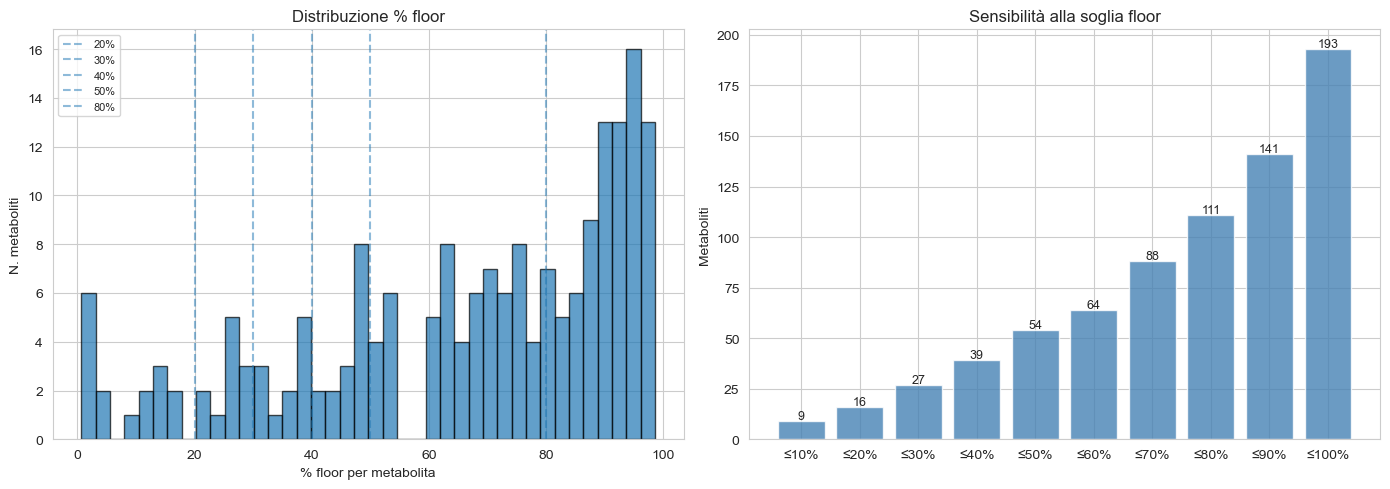


→ Con FLOOR_THR = 40%: 39/193 metaboliti selezionati per le analisi


In [34]:
# ══════════════════════════════════════════════════════════════════════
# 3. QUALITÀ DEI DATI & FLOOR EFFECT
# ══════════════════════════════════════════════════════════════════════

# ── Missingness ──────────────────────────────────────────────────────
total_vals = df_master[met_cols].size
total_nan  = df_master[met_cols].isna().sum().sum()
print("=" * 60)
print("QUALITÀ DEI DATI")
print("=" * 60)
print(f"Valori mancanti: {total_nan}/{total_vals} ({100*total_nan/total_vals:.2f}%)")
print(f"Metaboliti nel master: {len(met_cols)}")

# ── Floor effect ─────────────────────────────────────────────────────
floors    = df_master[met_cols].min(axis=0)
is_floor  = df_master[met_cols].eq(floors, axis=1)
pct_floor = (is_floor.mean(axis=0) * 100).sort_values(ascending=False)

print(f"\nFloor effect:")
print(f"  Media:   {pct_floor.mean():.1f}%")
print(f"  Mediana: {pct_floor.median():.1f}%")
print(f"  Max:     {pct_floor.max():.1f}% ({pct_floor.idxmax()})")

# ── Sensitivity alla soglia ──────────────────────────────────────────
thresholds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
surviving  = [int((pct_floor <= t).sum()) for t in thresholds]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(pct_floor.values, bins=40, edgecolor="black", alpha=0.7)
for thr in [20, 30, 40, 50, 80]:
    ax1.axvline(thr, ls="--", alpha=0.5, label=f"{thr}%")
ax1.set_xlabel("% floor per metabolita"); ax1.set_ylabel("N. metaboliti")
ax1.set_title("Distribuzione % floor"); ax1.legend(fontsize=8)

ax2.bar(range(len(thresholds)), surviving,
        tick_label=[f"≤{t}%" for t in thresholds], color="steelblue", alpha=0.8)
ax2.set_ylabel("Metaboliti"); ax2.set_title("Sensibilità alla soglia floor")
for i, v in enumerate(surviving):
    ax2.text(i, v + 1, str(v), ha="center", fontsize=9)

plt.tight_layout(); plt.show()

n_sel = int((pct_floor <= FLOOR_THR).sum())
print(f"\n→ Con FLOOR_THR = {FLOOR_THR}%: {n_sel}/{len(met_cols)} metaboliti selezionati per le analisi")

## 4. Descrizione della coorte

Analisi descrittiva delle variabili demografiche alla baseline (T1):
- **Età** alla baseline e ai diversi timepoint
- **Sesso** e distribuzione
- **BMI**
- Correlazione età–FI

DEMOGRAFIA — Baseline (T1)
Pazienti: 609

ETÀ alla baseline:
  Media ± SD: 72.7 ± 1.4 anni
  Mediana:    73 anni
  Range:      71 – 75 anni

ANNO DI NASCITA:
  Range: 1935 – 1939
1935     90
1936     94
1937    121
1938    142
1939    162

SESSO:
  F: 319 (52.4%)
  M: 290 (47.6%)

BMI alla baseline:
  Media ± SD: 27.8 ± 4.4
  Mediana:    27.3
  Range:      15.6 – 49.0

ETÀ per timepoint:
  T1 (anno 0): 72.7 ± 1.4 [71–75]
  T2 (anno 2): 74.7 ± 1.4 [73–77]
  T3 (anno 4): 76.7 ± 1.4 [75–79]
  T4 (anno 8): 80.7 ± 1.4 [79–83]


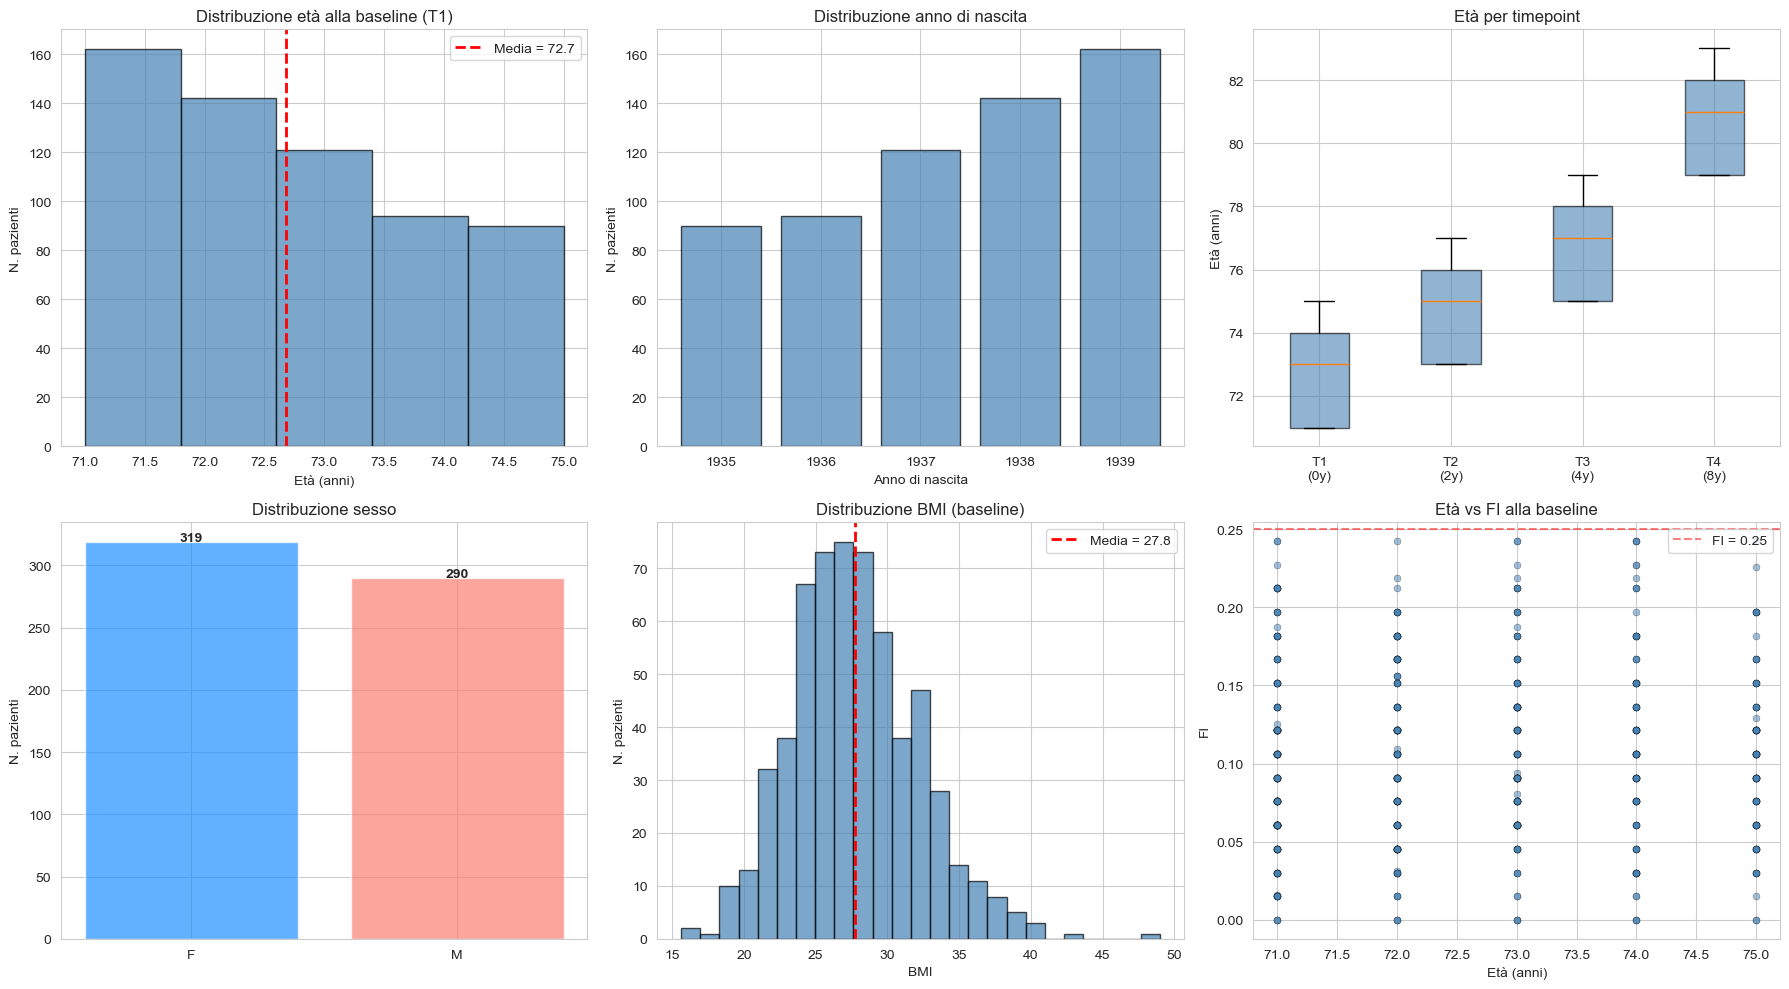


Correlazione Spearman età–FI (baseline): ρ = 0.046, p = 2.57e-01


In [35]:
# ══════════════════════════════════════════════════════════════════════
# C. EDA DEMOGRAFICA
# ══════════════════════════════════════════════════════════════════════

# ── Dati baseline (T1, una riga per paziente) ────────────────────────
bl = df_master[df_master["Time"] == 1].copy()

print("=" * 60)
print("DEMOGRAFIA — Baseline (T1)")
print("=" * 60)
print(f"Pazienti: {len(bl)}")
print(f"\nETÀ alla baseline:")
print(f"  Media ± SD: {bl['Age'].mean():.1f} ± {bl['Age'].std():.1f} anni")
print(f"  Mediana:    {bl['Age'].median():.0f} anni")
print(f"  Range:      {bl['Age'].min():.0f} – {bl['Age'].max():.0f} anni")
print(f"\nANNO DI NASCITA:")
print(f"  Range: {bl['annonascita'].min():.0f} – {bl['annonascita'].max():.0f}")
print(bl["annonascita"].value_counts().sort_index().to_string(header=False))

if "Sesso" in bl.columns:
    print(f"\nSESSO:")
    sex_counts = bl["Sesso"].value_counts()
    for s, n in sex_counts.items():
        label = "F" if s == 2 else ("M" if s == 1 else s)
        print(f"  {label}: {n} ({100*n/len(bl):.1f}%)")

if "BMI1" in bl.columns:
    bmi = pd.to_numeric(bl["BMI1"], errors="coerce").dropna()
    print(f"\nBMI alla baseline:")
    print(f"  Media ± SD: {bmi.mean():.1f} ± {bmi.std():.1f}")
    print(f"  Mediana:    {bmi.median():.1f}")
    print(f"  Range:      {bmi.min():.1f} – {bmi.max():.1f}")

# ── ETÀ PER TIMEPOINT ────────────────────────────────────────────────
print(f"\nETÀ per timepoint:")
for t in TIMES:
    sub = df_master[df_master["Time"] == t]
    print(f"  T{t} (anno {TIME_TO_YEARS[t]}): "
          f"{sub['Age'].mean():.1f} ± {sub['Age'].std():.1f} "
          f"[{sub['Age'].min():.0f}–{sub['Age'].max():.0f}]")

# ── GRAFICI ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribuzione età baseline
axes[0, 0].hist(bl["Age"], bins=5, edgecolor="black", alpha=0.7, color="steelblue")
axes[0, 0].axvline(bl["Age"].mean(), ls="--", c="red", linewidth=2,
                   label=f"Media = {bl['Age'].mean():.1f}")
axes[0, 0].set_xlabel("Età (anni)")
axes[0, 0].set_ylabel("N. pazienti")
axes[0, 0].set_title("Distribuzione età alla baseline (T1)")
axes[0, 0].legend()

# 2. Anno di nascita
anno_counts = bl["annonascita"].value_counts().sort_index()
axes[0, 1].bar(anno_counts.index.astype(int), anno_counts.values,
               color="steelblue", edgecolor="black", alpha=0.7)
axes[0, 1].set_xlabel("Anno di nascita")
axes[0, 1].set_ylabel("N. pazienti")
axes[0, 1].set_title("Distribuzione anno di nascita")

# 3. Boxplot età per timepoint
age_data = [df_master.loc[df_master["Time"] == t, "Age"].values for t in TIMES]
bp = axes[0, 2].boxplot(age_data, labels=[f"T{t}\n({TIME_TO_YEARS[t]}y)" for t in TIMES],
                        patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.6)
axes[0, 2].set_ylabel("Età (anni)")
axes[0, 2].set_title("Età per timepoint")

# 4. Sesso
if "Sesso" in bl.columns:
    sex_labels = bl["Sesso"].map({1: "M", 2: "F"}).fillna("?")
    sex_c = sex_labels.value_counts()
    axes[1, 0].bar(sex_c.index, sex_c.values, color=["dodgerblue", "salmon"], alpha=0.7)
    axes[1, 0].set_ylabel("N. pazienti")
    axes[1, 0].set_title("Distribuzione sesso")
    for i_b, (lab, val) in enumerate(sex_c.items()):
        axes[1, 0].text(i_b, val + 1, str(val), ha="center", fontweight="bold")

# 5. BMI
if "BMI1" in bl.columns:
    bmi_vals = pd.to_numeric(bl["BMI1"], errors="coerce").dropna()
    axes[1, 1].hist(bmi_vals, bins=25, edgecolor="black", alpha=0.7, color="steelblue")
    axes[1, 1].axvline(bmi_vals.mean(), ls="--", c="red", linewidth=2,
                       label=f"Media = {bmi_vals.mean():.1f}")
    axes[1, 1].set_xlabel("BMI")
    axes[1, 1].set_ylabel("N. pazienti")
    axes[1, 1].set_title("Distribuzione BMI (baseline)")
    axes[1, 1].legend()

# 6. Scatter: Età vs FI alla baseline
axes[1, 2].scatter(bl["Age"], bl["FI"], s=25, alpha=0.5, c="steelblue", edgecolors="k", linewidth=0.3)
axes[1, 2].axhline(FRAIL_THR, ls="--", c="red", alpha=0.5, label=f"FI = {FRAIL_THR}")
axes[1, 2].set_xlabel("Età (anni)")
axes[1, 2].set_ylabel("FI")
axes[1, 2].set_title("Età vs FI alla baseline")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

# ── CORRELAZIONE ETÀ-FI ─────────────────────────────────────────────
rho, p_rho = spearmanr(bl["Age"], bl["FI"])
print(f"\nCorrelazione Spearman età–FI (baseline): ρ = {rho:.3f}, p = {p_rho:.2e}")

## 5. Definizione gruppi di fragilità

**Definizione:** Frail = **FI ≥ 0.25**

- **Per visita:** frail / not-frail a ogni timepoint
- **Ever-frail:** FI ≥ 0.25 in almeno una visita (definizione usata in TCAM)
- **Never-frail:** FI < 0.25 in tutte le visite
- **Stato a T4:** confronto con definizione ever-frail

Frailty per visita:


,n_frail,n_total,n_not_frail,pct_frail
T1 (anno 0),0,609,609,0.0
T2 (anno 2),24,609,585,3.9
T3 (anno 4),35,609,574,5.7
T4 (anno 8),147,609,462,24.1



Ever-frail: 152,  Never-frail: 457
Frail a T4: 147, Not-frail a T4: 462

Overlap tra definizioni:


,Gruppo,N
0,Ever-frail,152
1,Frail a T4,147
2,In comune,147
3,Solo ever-frail,5
4,Solo frail a T4,0



Età alla baseline per gruppo:
  Never-frail: 72.6 ± 1.4 [71–75]
  Ever-frail: 72.8 ± 1.4 [71–75]


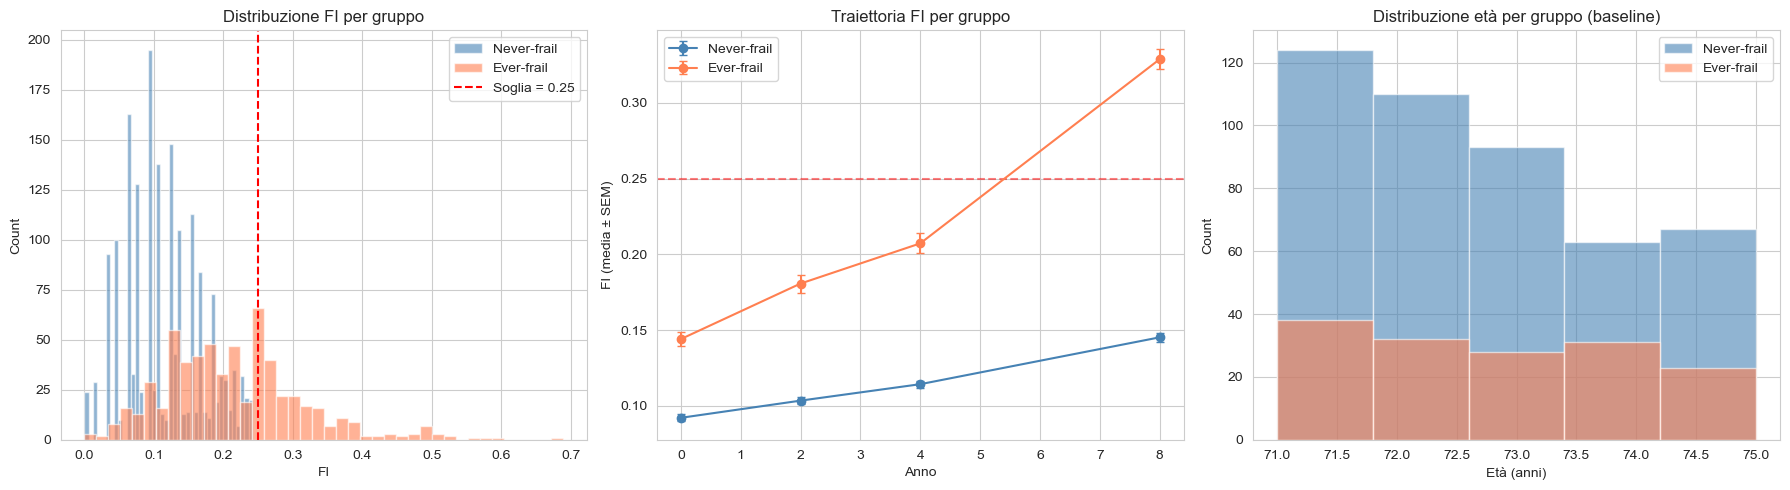

In [36]:
# ── FRAILTY PER VISITA ────────────────────────────────────────────────
df_master["Frail"] = (df_master["FI"] >= FRAIL_THR).astype(int)
frail_per_visit = df_master.groupby("Time")["Frail"].agg(["sum", "count"])
frail_per_visit.columns = ["n_frail", "n_total"]
frail_per_visit["n_not_frail"] = frail_per_visit["n_total"] - frail_per_visit["n_frail"]
frail_per_visit["pct_frail"]   = (frail_per_visit["n_frail"] / frail_per_visit["n_total"] * 100).round(1)
frail_per_visit.index = [f"T{t} (anno {TIME_TO_YEARS[t]})" for t in frail_per_visit.index]
print("Frailty per visita:")
display(frail_per_visit)

# ── EVER / NEVER FRAIL ───────────────────────────────────────────────
ever_frail_map = (
    df_master.groupby("Code")["FI"].max() >= FRAIL_THR
).map({True: "Ever-frail", False: "Never-frail"})
df_master["Group"] = df_master["Code"].map(ever_frail_map)
df_master["Group"] = pd.Categorical(df_master["Group"],
                                     categories=["Never-frail", "Ever-frail"])
n_ef = (ever_frail_map == "Ever-frail").sum()
n_nf = (ever_frail_map == "Never-frail").sum()
print(f"\nEver-frail: {n_ef},  Never-frail: {n_nf}")

# ── STATO A T4 ───────────────────────────────────────────────────────
t4 = df_master.loc[df_master["Time"] == 4, ["Code", "FI"]].copy()
t4["frail_T4"] = t4["FI"] >= FRAIL_THR
n_frail_t4 = t4["frail_T4"].sum()
print(f"Frail a T4: {n_frail_t4}, Not-frail a T4: {len(t4) - n_frail_t4}")

# ── OVERLAP ──────────────────────────────────────────────────────────
ever_ids = set(ever_frail_map[ever_frail_map == "Ever-frail"].index)
t4_ids   = set(t4.loc[t4["frail_T4"], "Code"])
overlap = pd.DataFrame({
    "Gruppo": ["Ever-frail", "Frail a T4", "In comune",
               "Solo ever-frail", "Solo frail a T4"],
    "N": [len(ever_ids), len(t4_ids), len(ever_ids & t4_ids),
          len(ever_ids - t4_ids), len(t4_ids - ever_ids)]
})
print("\nOverlap tra definizioni:")
display(overlap)

# ── ETÀ PER GRUPPO ───────────────────────────────────────────────────
bl_grp = df_master[df_master["Time"] == 1].copy()
print("\nEtà alla baseline per gruppo:")
for grp in ["Never-frail", "Ever-frail"]:
    sub = bl_grp[bl_grp["Group"] == grp]
    print(f"  {grp}: {sub['Age'].mean():.1f} ± {sub['Age'].std():.1f} "
          f"[{sub['Age'].min():.0f}–{sub['Age'].max():.0f}]")

# ── PLOT ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# FI distribution by group
for grp in ["Never-frail", "Ever-frail"]:
    sub = df_master[df_master["Group"] == grp]
    axes[0].hist(sub["FI"], bins=40, alpha=0.6, label=grp, color=colors[grp])
axes[0].axvline(FRAIL_THR, ls="--", c="red", label=f"Soglia = {FRAIL_THR}")
axes[0].set_xlabel("FI"); axes[0].set_ylabel("Count")
axes[0].set_title("Distribuzione FI per gruppo"); axes[0].legend()

# FI trajectory
fi_mean = df_master.groupby(["Years", "Group"])["FI"].agg(["mean", "sem"]).reset_index()
for grp in ["Never-frail", "Ever-frail"]:
    sub = fi_mean[fi_mean["Group"] == grp]
    axes[1].errorbar(sub["Years"], sub["mean"], yerr=sub["sem"],
                     marker="o", label=grp, color=colors[grp], capsize=3)
axes[1].axhline(FRAIL_THR, ls="--", c="red", alpha=0.5)
axes[1].set_xlabel("Anno"); axes[1].set_ylabel("FI (media ± SEM)")
axes[1].set_title("Traiettoria FI per gruppo"); axes[1].legend()

# Age distribution by group (baseline)
for grp in ["Never-frail", "Ever-frail"]:
    sub = bl_grp[bl_grp["Group"] == grp]
    axes[2].hist(sub["Age"], bins=5, alpha=0.6, label=grp, color=colors[grp])
axes[2].set_xlabel("Età (anni)"); axes[2].set_ylabel("Count")
axes[2].set_title("Distribuzione età per gruppo (baseline)"); axes[2].legend()

plt.tight_layout(); plt.show()

## 6. Transizioni di fragilità — Sankey

Diagramma Sankey che mostra come i pazienti transitano tra stato frail e not-frail
tra ogni coppia di visite consecutive.

In [37]:
def build_sankey(df_src, frail_thr, title="Transizioni fragilità"):
    pivot = df_src.pivot(index="Code", columns="Time", values="FI")
    status = (pivot >= frail_thr).astype(int)
    labels, sources, targets, values, link_colors = [], [], [], [], []
    time_list = sorted(status.columns)

    for i, t in enumerate(time_list):
        n_nf = (status[t] == 0).sum()
        n_fr = (status[t] == 1).sum()
        labels.append(f"T{t} NF ({n_nf})")
        labels.append(f"T{t} F ({n_fr})")

    colors_map = {"NF→NF": "rgba(70,130,180,0.4)", "NF→F": "rgba(255,127,80,0.5)",
                  "F→NF": "rgba(144,238,144,0.5)", "F→F": "rgba(220,20,60,0.4)"}
    for i in range(len(time_list) - 1):
        t_from, t_to = time_list[i], time_list[i + 1]
        for s_from in [0, 1]:
            for s_to in [0, 1]:
                cnt = int(((status[t_from] == s_from) & (status[t_to] == s_to)).sum())
                if cnt == 0:
                    continue
                sources.append(i * 2 + s_from)
                targets.append((i + 1) * 2 + s_to)
                values.append(cnt)
                lbl = ("F" if s_from else "NF") + "→" + ("F" if s_to else "NF")
                link_colors.append(colors_map[lbl])

    fig = go.Figure(go.Sankey(
        node=dict(pad=15, thickness=20, label=labels,
                  color=["steelblue" if "NF" in l else "coral" for l in labels]),
        link=dict(source=sources, target=targets, value=values, color=link_colors)))
    fig.update_layout(title_text=title, font_size=12, width=800, height=400)
    fig.show()

    trans_rows = []
    for i in range(len(time_list) - 1):
        t_from, t_to = time_list[i], time_list[i + 1]
        for s_from in [0, 1]:
            for s_to in [0, 1]:
                cnt = int(((status[t_from] == s_from) & (status[t_to] == s_to)).sum())
                trans_rows.append({"Da": f"T{t_from}", "A": f"T{t_to}",
                    "Stato_da": "Frail" if s_from else "Not-frail",
                    "Stato_a":  "Frail" if s_to   else "Not-frail", "N": cnt})
    display(pd.DataFrame(trans_rows))

build_sankey(df_master, FRAIL_THR, title="Transizioni fragilità (FI ≥ 0.25)")

,Da,A,Stato_da,Stato_a,N
0,T1,T2,Not-frail,Not-frail,585
1,T1,T2,Not-frail,Frail,24
2,T1,T2,Frail,Not-frail,0
3,T1,T2,Frail,Frail,0
4,T2,T3,Not-frail,Not-frail,566
5,T2,T3,Not-frail,Frail,19
6,T2,T3,Frail,Not-frail,8
7,T2,T3,Frail,Frail,16
8,T3,T4,Not-frail,Not-frail,458
9,T3,T4,Not-frail,Frail,116


## 7. Floor effect per gruppo

Verificare se il floor (valore minimo) è equidistribuito tra Ever-frail e Never-frail.
Un floor sbilanciato potrebbe confondere i risultati delle analisi successive.

**Metodo:** Fisher exact test per ogni metabolita (floor vs non-floor × gruppo), con FDR-BH.

H-1. FLOOR PER GRUPPO — Fisher exact
Metaboliti con floor sbilanciato (FDR<0.05): 31/193
Metaboliti con diff > 5 pp: 39


,metabolite,pct_floor_EF,pct_floor_NF,diff_pp,OR,p_fisher,q_fisher
140,126048,68.9145,58.6980,10.2164,1.5599,0.0000,0.0005
15,Methylgallic acid-O-sulphate,54.7697,44.8031,9.9667,1.4918,0.0000,0.0007
108,88195,22.8618,13.4026,9.4592,1.9149,0.0000,0.0000
109,88933,37.1711,28.1182,9.0529,1.5124,0.0000,0.0009
72,Vanillin 4-sulfate,47.2039,56.1816,-8.9777,0.6973,0.0001,0.0027
165,136343,55.2632,46.9365,8.3266,1.3965,0.0004,0.0057
152,129795,80.4276,88.0744,-7.6468,0.5564,0.0000,0.0005
147,127949,80.4276,72.9759,7.4517,1.5217,0.0002,0.0038
48,Phloretin,33.0592,25.6565,7.4028,1.4310,0.0005,0.0064
129,121512,19.0789,12.0350,7.0439,1.7233,0.0000,0.0007


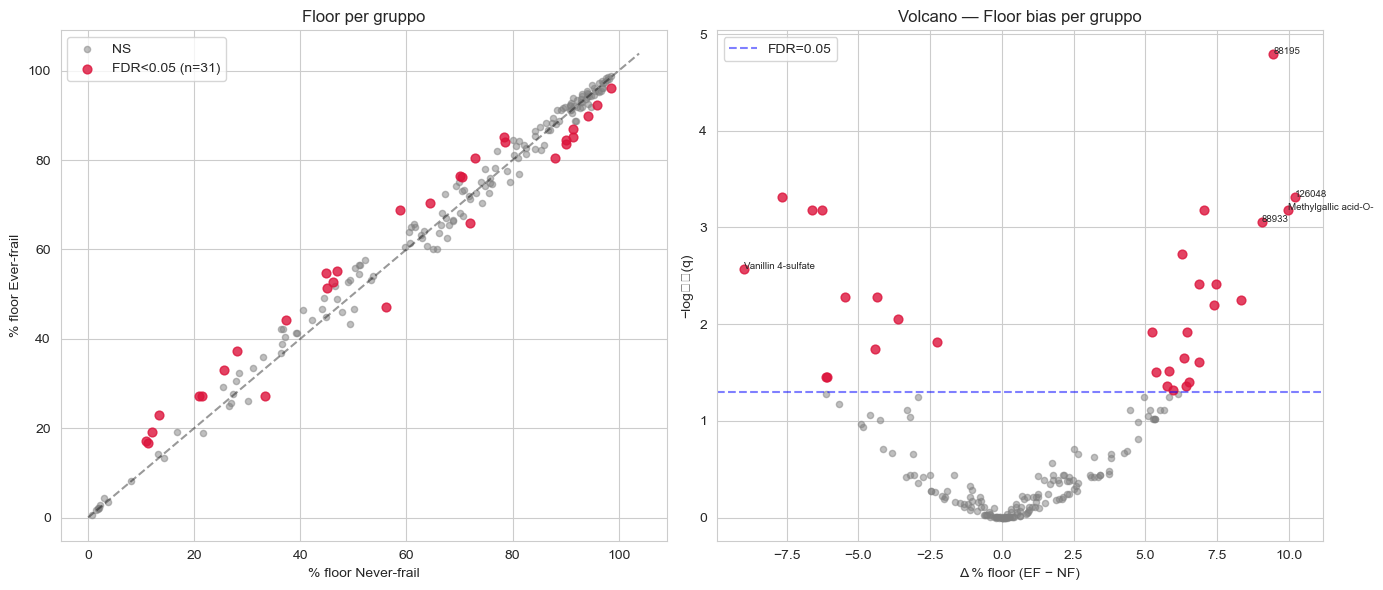

✓ Salvato: data/floor_per_gruppo_fisher.csv


In [38]:
# ══════════════════════════════════════════════════════════════════════
# H-1. FLOOR PER GRUPPO — Fisher exact + volcano + scatter
# ══════════════════════════════════════════════════════════════════════

# ── Definisci floor per ogni metabolita ──────────────────────────────
floors_g = df_master[met_cols].min(axis=0)
is_floor_g = df_master[met_cols].eq(floors_g, axis=1)

ef_mask = df_master["Group"] == "Ever-frail"
nf_mask = df_master["Group"] == "Never-frail"
pct_ef = is_floor_g[ef_mask].mean(axis=0) * 100
pct_nf = is_floor_g[nf_mask].mean(axis=0) * 100
n_ef_tot = ef_mask.sum()
n_nf_tot = nf_mask.sum()

# ── Fisher exact test ────────────────────────────────────────────────
fisher_rows = []
for m in met_cols:
    a = is_floor_g.loc[ef_mask, m].sum()
    b = n_ef_tot - a
    c = is_floor_g.loc[nf_mask, m].sum()
    d = n_nf_tot - c
    odds_r, p_fisher = fisher_exact(np.array([[a, b], [c, d]]), alternative="two-sided")
    fisher_rows.append({
        "metabolite": m, "pct_floor_EF": pct_ef[m], "pct_floor_NF": pct_nf[m],
        "diff_pp": pct_ef[m] - pct_nf[m], "abs_diff_pp": abs(pct_ef[m] - pct_nf[m]),
        "OR": odds_r, "p_fisher": p_fisher, "n_floor_EF": int(a), "n_floor_NF": int(c),
    })

floor_fisher_df = pd.DataFrame(fisher_rows)
floor_fisher_df["q_fisher"] = fdr_bh(floor_fisher_df["p_fisher"].values)
floor_fisher_df["log2_OR"] = np.log2(floor_fisher_df["OR"].replace({0: np.nan, np.inf: np.nan}))

n_sig_floor = (floor_fisher_df["q_fisher"] < 0.05).sum()
print(f"{'='*60}")
print(f"H-1. FLOOR PER GRUPPO — Fisher exact")
print(f"{'='*60}")
print(f"Metaboliti con floor sbilanciato (FDR<0.05): {n_sig_floor}/{len(met_cols)}")
print(f"Metaboliti con diff > 5 pp: {(floor_fisher_df['abs_diff_pp'] > 5).sum()}")
display(floor_fisher_df.sort_values("abs_diff_pp", ascending=False).head(15)[
    ["metabolite", "pct_floor_EF", "pct_floor_NF", "diff_pp", "OR", "p_fisher", "q_fisher"]
].round(4))

# ── Grafici ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sig_mask_f = floor_fisher_df["q_fisher"] < 0.05
ax1.scatter(floor_fisher_df.loc[~sig_mask_f, "pct_floor_NF"],
            floor_fisher_df.loc[~sig_mask_f, "pct_floor_EF"], s=20, alpha=0.5, c="grey", label="NS")
ax1.scatter(floor_fisher_df.loc[sig_mask_f, "pct_floor_NF"],
            floor_fisher_df.loc[sig_mask_f, "pct_floor_EF"],
            s=40, alpha=0.8, c="crimson", label=f"FDR<0.05 (n={n_sig_floor})")
lim = max(pct_nf.max(), pct_ef.max()) + 5
ax1.plot([0, lim], [0, lim], "k--", alpha=0.4)
ax1.set_xlabel("% floor Never-frail"); ax1.set_ylabel("% floor Ever-frail")
ax1.set_title("Floor per gruppo"); ax1.legend()

neglog = -np.log10(floor_fisher_df["q_fisher"].clip(lower=1e-20))
ax2.scatter(floor_fisher_df.loc[~sig_mask_f, "diff_pp"], neglog[~sig_mask_f], s=20, alpha=0.5, c="grey")
ax2.scatter(floor_fisher_df.loc[sig_mask_f, "diff_pp"], neglog[sig_mask_f], s=40, alpha=0.8, c="crimson")
ax2.axhline(-np.log10(0.05), color="blue", linestyle="--", alpha=0.5, label="FDR=0.05")
ax2.set_xlabel("Δ % floor (EF − NF)"); ax2.set_ylabel("−log₁₀(q)")
ax2.set_title("Volcano — Floor bias per gruppo"); ax2.legend()
for _, r in floor_fisher_df.nlargest(5, "abs_diff_pp").iterrows():
    ax2.annotate(str(r["metabolite"])[:20], (r["diff_pp"], -np.log10(max(r["q_fisher"], 1e-20))), fontsize=7)

plt.tight_layout(); plt.show()

floor_fisher_df.sort_values("q_fisher").to_csv(f"{OUTDIR}/floor_per_gruppo_fisher.csv", index=False)
print(f"✓ Salvato: {OUTDIR}/floor_per_gruppo_fisher.csv")

## 8. Confronto dell'età tra i gruppi

La coorte InveCe è ristretta alle coorti di nascita 1935–1939 → range molto stretto (71–75 anni alla baseline).
Questo è un punto di forza: l'effetto confondente dell'età è naturalmente ridotto.

- **Test:** Mann-Whitney U (non-parametrico, appropriato per distribuzione discreta)
- **Interpretazione:** se p < 0.05, l'età andrebbe inclusa come covariata nei modelli

CONFRONTO ETÀ — Ever-frail vs Never-frail (Baseline T1)

  Never-frail (n=457): 72.65 ± 1.39 [71–75]
  Ever-frail  (n=152): 72.80 ± 1.41 [71–75]

  Mann-Whitney U = 36792,  p = 0.2618
  Rank-biserial r = -0.059
  Spearman età–FI baseline: ρ = 0.046, p = 2.566e-01


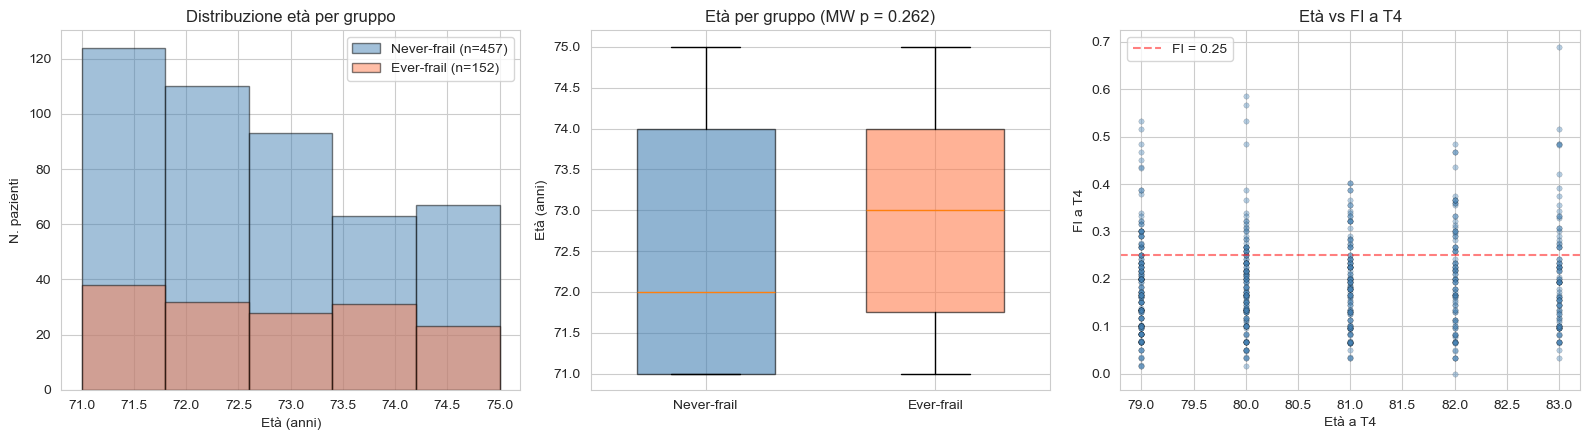


✓ Nessuna differenza significativa nell'età tra i gruppi.
  Range stretto (5 anni) per design della coorte InveCe.
  L'età può comunque essere utile nei modelli predittivi.


In [39]:
# ══════════════════════════════════════════════════════════════════════
# 8. CONFRONTO ETÀ TRA GRUPPI
# ══════════════════════════════════════════════════════════════════════

bl = df_master[df_master["Time"] == 1].copy()
age_ef = bl.loc[bl["Group"] == "Ever-frail", "Age"].values
age_nf = bl.loc[bl["Group"] == "Never-frail", "Age"].values

# Mann-Whitney U test
stat_mw, p_mw = mannwhitneyu(age_ef, age_nf, alternative="two-sided")
r_rb = 1 - 2 * stat_mw / (len(age_ef) * len(age_nf))

print("=" * 60)
print("CONFRONTO ETÀ — Ever-frail vs Never-frail (Baseline T1)")
print("=" * 60)
print(f"\n  Never-frail (n={len(age_nf)}): {age_nf.mean():.2f} ± {age_nf.std():.2f} "
      f"[{age_nf.min():.0f}–{age_nf.max():.0f}]")
print(f"  Ever-frail  (n={len(age_ef)}): {age_ef.mean():.2f} ± {age_ef.std():.2f} "
      f"[{age_ef.min():.0f}–{age_ef.max():.0f}]")
print(f"\n  Mann-Whitney U = {stat_mw:.0f},  p = {p_mw:.4f}")
print(f"  Rank-biserial r = {r_rb:.3f}")

rho_bl, p_rho_bl = spearmanr(bl["Age"], bl["FI"])
print(f"  Spearman età–FI baseline: ρ = {rho_bl:.3f}, p = {p_rho_bl:.3e}")

# ── Visualizzazione ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for grp, col in colors.items():
    sub = bl.loc[bl["Group"] == grp, "Age"]
    axes[0].hist(sub, bins=5, alpha=0.5, label=f"{grp} (n={len(sub)})", color=col, edgecolor="k")
axes[0].set_xlabel("Età (anni)"); axes[0].set_ylabel("N. pazienti")
axes[0].set_title("Distribuzione età per gruppo"); axes[0].legend()

bp = axes[1].boxplot([age_nf, age_ef], labels=["Never-frail", "Ever-frail"],
                     patch_artist=True, widths=0.6)
for box, c in zip(bp["boxes"], [colors["Never-frail"], colors["Ever-frail"]]):
    box.set_facecolor(c); box.set_alpha(0.6)
axes[1].set_ylabel("Età (anni)")
axes[1].set_title(f"Età per gruppo (MW p = {p_mw:.3f})")

t4_data = df_master[df_master["Time"] == 4].copy()
axes[2].scatter(t4_data["Age"], t4_data["FI"], s=15, alpha=0.4,
                c="steelblue", edgecolors="k", linewidth=0.2)
axes[2].axhline(FRAIL_THR, ls="--", c="red", alpha=0.5, label=f"FI = {FRAIL_THR}")
axes[2].set_xlabel("Età a T4"); axes[2].set_ylabel("FI a T4")
axes[2].set_title("Età vs FI a T4"); axes[2].legend()

plt.tight_layout(); plt.show()

if p_mw < 0.05:
    print("\n⚠️ Differenza significativa: l'età va inclusa come covariata nei modelli.")
else:
    print("\n✓ Nessuna differenza significativa nell'età tra i gruppi.")
    print("  Range stretto (5 anni) per design della coorte InveCe.")
    print("  L'età può comunque essere utile nei modelli predittivi.")

## 9. Variazione temporale nei soggetti Never-frail

> Suggerimento della prof: *"analizzare quelli che rimangono sempre FIT per vedere se ci sono variazioni nel tempo dei metaboliti"*

Per i soggetti **sempre not-frail** (FI < 0.25 a tutte le visite), testiamo se i livelli
di ogni metabolita cambiano significativamente nel tempo.

**Metodo:** Test di Friedman (alternativa non parametrica alla RM-ANOVA a 1 via),
appropriato per dati metabolomici con distribuzione asimmetrica e misure ripetute su 4 timepoint.

Soggetti Never-frail: 457
Metaboliti analizzati (floor ≤ 40%): 39

Metaboliti con variazione temporale significativa (FDR<0.05): 39/39


,metabolite,chi2,p_friedman,q_friedman,n
0,Daidzein,827.9492,0.0,0.0,457
1,Phloretin,760.6324,0.0,0.0,457
2,Pinoresinol,669.1201,0.0,0.0,457
3,131646,590.5998,0.0,0.0,457
4,70569,562.5597,0.0,0.0,457
5,133960,504.2902,0.0,0.0,457
6,myo-Inositol,496.3513,0.0,0.0,457
7,Isorhamnetin,483.3546,0.0,0.0,457
8,"1-(2,6-Dihydroxy-4-methoxyphenyl)-3-phenyl-1-p...",446.2387,0.0,0.0,457
9,107237,437.2924,0.0,0.0,457


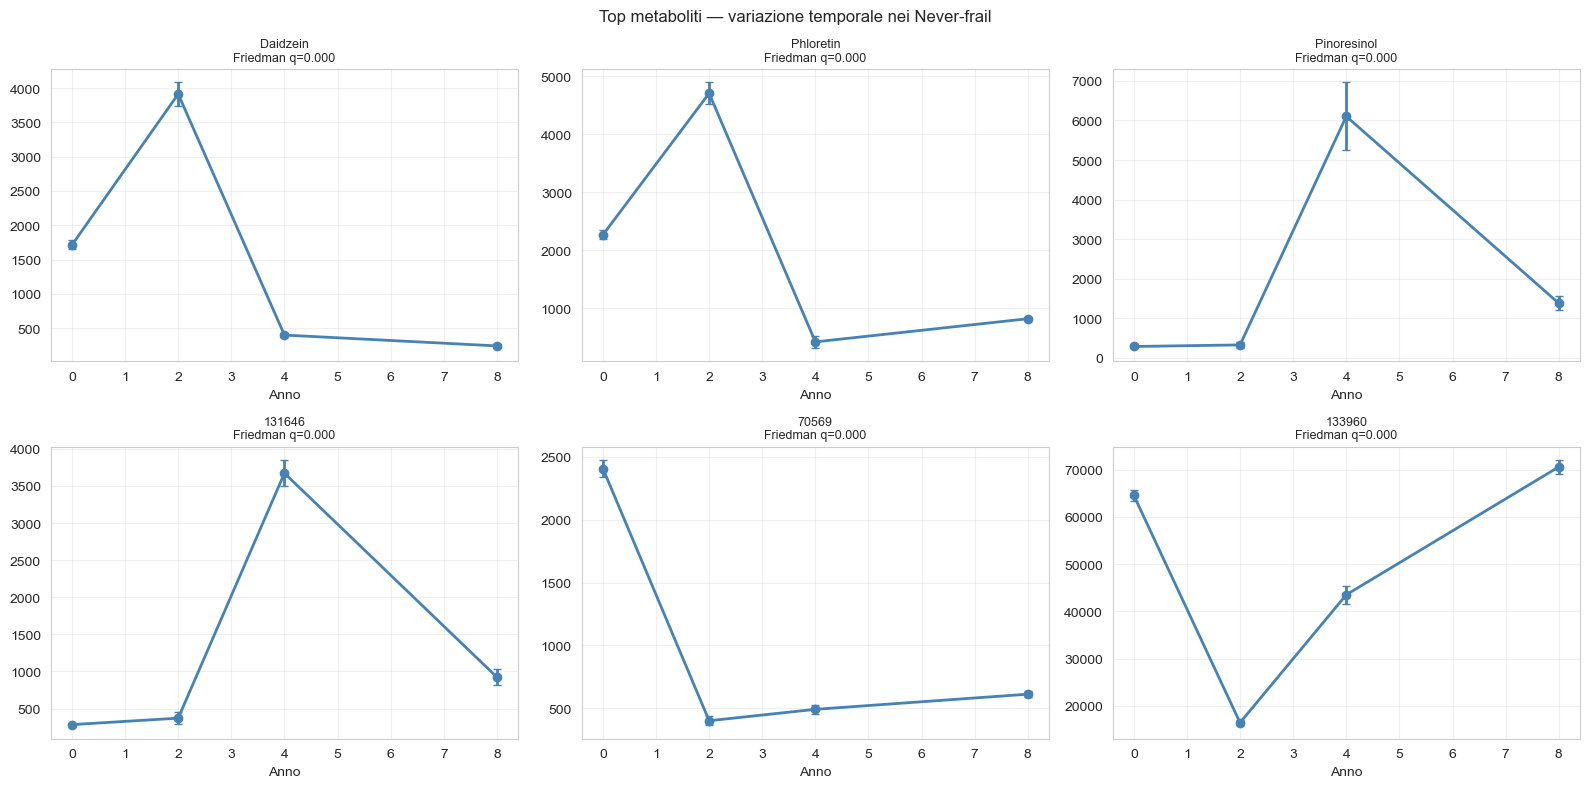

✓ Salvato: data/rm_anova_neverfrail.csv


In [40]:
# ══════════════════════════════════════════════════════════════════════
# 9. RM-ANOVA (FRIEDMAN) — SOGGETTI NEVER-FRAIL
# ══════════════════════════════════════════════════════════════════════

nf_data = df_master[df_master["Group"] == "Never-frail"].copy()
nf_codes = nf_data["Code"].unique()
mets_sel = pct_floor[pct_floor <= FLOOR_THR].index.tolist()

print(f"Soggetti Never-frail: {len(nf_codes)}")
print(f"Metaboliti analizzati (floor ≤ {FLOOR_THR}%): {len(mets_sel)}")

friedman_rows = []
for m in mets_sel:
    pivot = nf_data.pivot(index="Code", columns="Time", values=m).dropna()
    if len(pivot) < 10:
        continue
    groups = [pivot[t].values for t in TIMES]
    try:
        stat, p = friedmanchisquare(*groups)
        friedman_rows.append({"metabolite": m, "chi2": stat, "p_friedman": p, "n": len(pivot)})
    except Exception:
        pass

friedman_df = pd.DataFrame(friedman_rows).sort_values("p_friedman").reset_index(drop=True)
friedman_df["q_friedman"] = fdr_bh(friedman_df["p_friedman"].values)
n_sig_fried = (friedman_df["q_friedman"] < 0.05).sum()

print(f"\nMetaboliti con variazione temporale significativa (FDR<0.05): "
      f"{n_sig_fried}/{len(friedman_df)}")
display(friedman_df.head(15)[["metabolite", "chi2", "p_friedman", "q_friedman", "n"]].round(4))

# ── Visualizzazione: top 6 ───────────────────────────────────────────
n_show = min(6, max(n_sig_fried, 6))
top_fried = friedman_df.head(n_show)
if len(top_fried) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, (_, row) in zip(axes.ravel(), top_fried.iterrows()):
        m = row["metabolite"]
        gm = nf_data.groupby("Years")[m].agg(["mean", "sem"])
        ax.errorbar(gm.index, gm["mean"], yerr=gm["sem"],
                    marker="o", color=colors["Never-frail"], capsize=3, linewidth=2)
        ax.set_title(f"{m[:25]}\nFriedman q={row['q_friedman']:.3f}", fontsize=9)
        ax.set_xlabel("Anno"); ax.grid(alpha=0.3)
    for j in range(len(top_fried), 6):
        axes.ravel()[j].set_visible(False)
    plt.suptitle("Top metaboliti — variazione temporale nei Never-frail", fontsize=12)
    plt.tight_layout(); plt.show()

friedman_df.to_csv(f"{OUTDIR}/rm_anova_neverfrail.csv", index=False)
print(f"✓ Salvato: {OUTDIR}/rm_anova_neverfrail.csv")

## 10. Analisi univariata — gruppi (Ever-frail vs Never-frail)

Due approcci complementari che **sostituiscono i GEE** (rimossi per problemi di convergenza):

1. **LMM:** `log₂(metabolita) ~ Group × Years + (1|Code)`
   - Tiene conto delle misure ripetute tramite random intercept per soggetto
   - Testa effetto medio del gruppo e interazione gruppo×tempo
   - Più stabile dei GEE su questo dataset

2. **Mann-Whitney U per timepoint** (stato frail **attuale**, non ever-frail)
   - Come suggerito dalla prof: *"fare un MW tra F e non F per ogni time point"*
   - Usa lo stato frail reale a ogni visita (FI ≥ 0.25)
   - A T1 nessuno è frail → nessun confronto possibile

Metaboliti analizzati (floor ≤ 40%): 39

1. LMM: log₂(metabolita) ~ Group × Years + (1|Code)
Effetto gruppo (FDR<0.05): 1/39
Interazione gruppo×tempo (FDR<0.05): 17/39


,metabolite,beta_group,q_group,beta_interaction,q_interaction
0,Resveratrol-O-glucuronide,1.3444,0.0050,-0.4526,0.0000
1,88195,0.1828,0.9762,-0.3514,0.0000
2,Phloretin,0.5911,0.6704,-0.3878,0.0000
3,121512,0.1090,1.0000,-0.3267,0.0001
4,Saccharin,-0.5090,0.6989,0.3022,0.0001
5,Caffeine,0.8074,0.6704,-0.4425,0.0003
6,Uric acid,0.0686,0.9762,-0.0907,0.0004
7,Pyrogallol,0.9810,0.1621,-0.3069,0.0004
8,Daidzein,-0.1597,0.9762,0.2321,0.0005
9,70569,0.2224,0.9762,-0.2844,0.0005



2. Mann-Whitney U per timepoint (stato frail ATTUALE a ogni visita)
   Nota: a T1 nessuno è frail → nessun confronto possibile

  T1 (anno 0): 0 frail → 0/39 sig.
  T2 (anno 2): 24 frail → 0/39 sig.
  T3 (anno 4): 35 frail → 0/39 sig.
  T4 (anno 8): 147 frail → 26/39 sig.


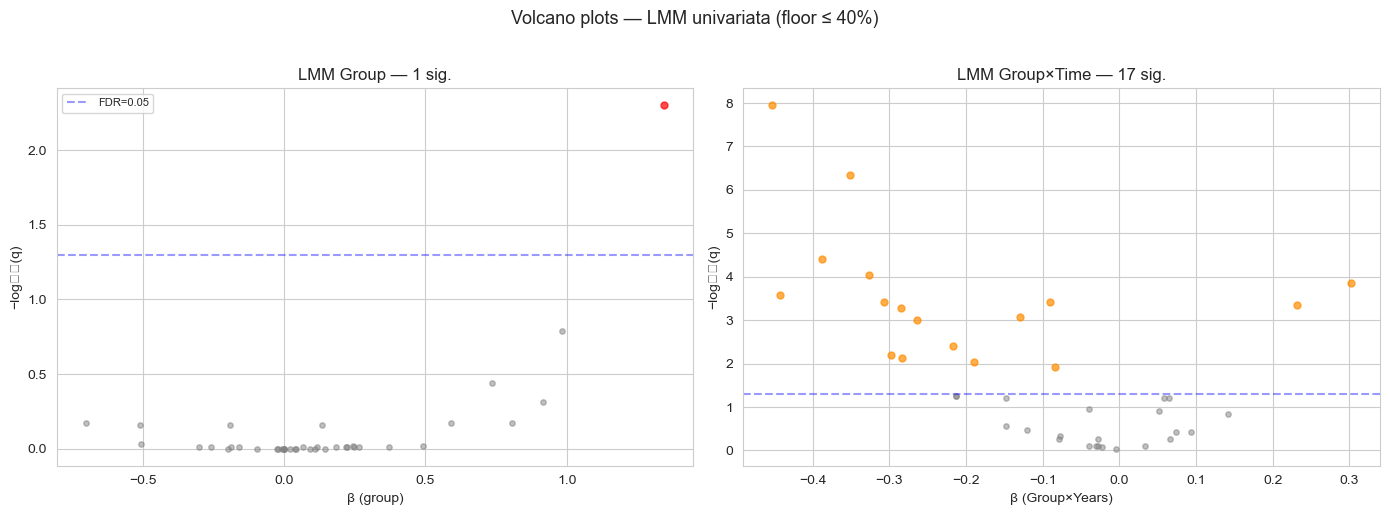

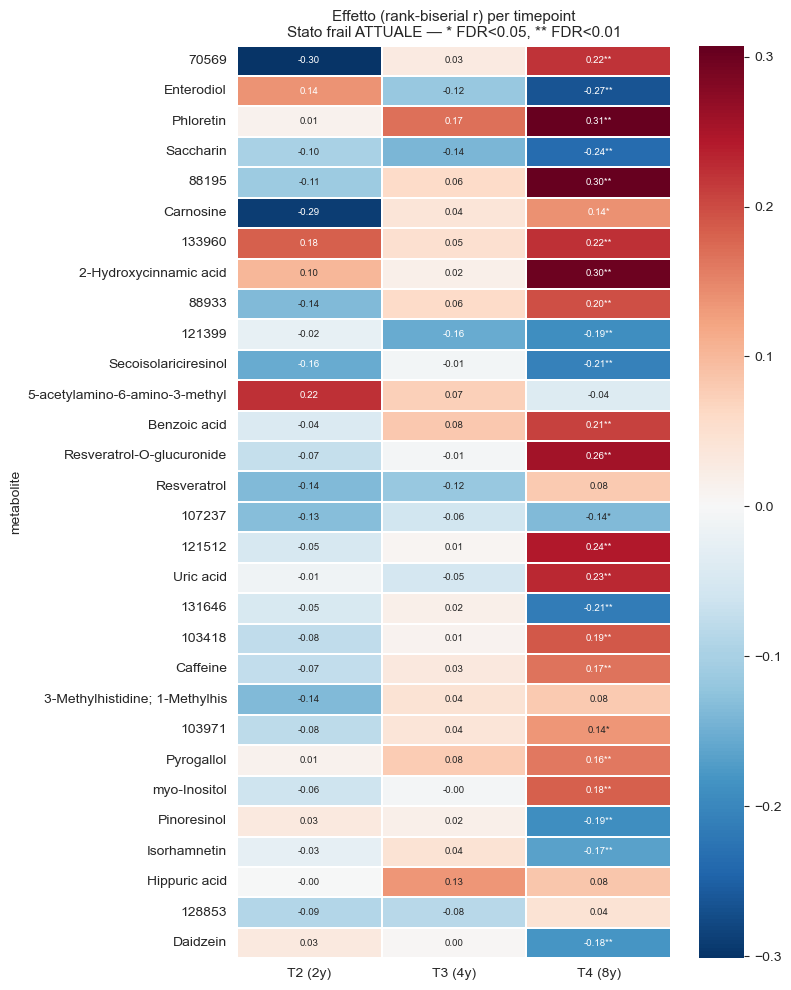


✓ Salvati: univariate_lmm_group.csv, univariate_mw_actual_status.csv


In [41]:
# ══════════════════════════════════════════════════════════════════════
# 10. UNIVARIATA — GRUPPI
# ══════════════════════════════════════════════════════════════════════

mets_univ = pct_floor[pct_floor <= FLOOR_THR].index.tolist()
df_master["Group_bin"] = (df_master["Group"] == "Ever-frail").astype(int)
print(f"Metaboliti analizzati (floor ≤ {FLOOR_THR}%): {len(mets_univ)}")

# ── 1. LMM GROUP × TIME ─────────────────────────────────────────────
print("\n" + "=" * 72)
print("1. LMM: log₂(metabolita) ~ Group × Years + (1|Code)")
print("=" * 72)

lmm_rows = []
for m in mets_univ:
    dat = pd.DataFrame({
        "y": np.log2(df_master[m].clip(lower=1e-12).astype(float)),
        "group": df_master["Group_bin"].astype(float),
        "years": df_master["Years"].astype(float),
        "code": df_master["Code"]}).dropna()
    if dat["group"].nunique() < 2 or dat["code"].nunique() < 5:
        continue
    try:
        fit = smf.mixedlm("y ~ group * years", data=dat,
                           groups=dat["code"]).fit(reml=False, method="lbfgs")
        lmm_rows.append({
            "metabolite": m,
            "beta_group": fit.params.get("group", np.nan),
            "p_group": fit.pvalues.get("group", np.nan),
            "beta_years": fit.params.get("years", np.nan),
            "p_years": fit.pvalues.get("years", np.nan),
            "beta_interaction": fit.params.get("group:years", np.nan),
            "p_interaction": fit.pvalues.get("group:years", np.nan)})
    except Exception:
        pass

lmm_grp_df = pd.DataFrame(lmm_rows).sort_values("p_interaction").reset_index(drop=True)
lmm_grp_df["q_group"] = fdr_bh(lmm_grp_df["p_group"].values)
lmm_grp_df["q_interaction"] = fdr_bh(lmm_grp_df["p_interaction"].values)
n_sig_grp = (lmm_grp_df["q_group"] < 0.05).sum()
n_sig_int = (lmm_grp_df["q_interaction"] < 0.05).sum()
print(f"Effetto gruppo (FDR<0.05): {n_sig_grp}/{len(lmm_grp_df)}")
print(f"Interazione gruppo×tempo (FDR<0.05): {n_sig_int}/{len(lmm_grp_df)}")
display(lmm_grp_df.head(15)[
    ["metabolite", "beta_group", "q_group", "beta_interaction", "q_interaction"]].round(4))

# ── 2. MANN-WHITNEY PER TIMEPOINT (STATO ATTUALE) ────────────────────
print("\n" + "=" * 72)
print("2. Mann-Whitney U per timepoint (stato frail ATTUALE a ogni visita)")
print("=" * 72)
print("   Nota: a T1 nessuno è frail → nessun confronto possibile\n")

mw_rows = []
for m in mets_univ:
    row = {"metabolite": m}
    for t in TIMES:
        mask_t = df_master["Time"] == t
        frail_t = df_master.loc[mask_t, "FI"] >= FRAIL_THR
        x = df_master.loc[mask_t & frail_t, m].dropna().values
        y = df_master.loc[mask_t & ~frail_t, m].dropna().values
        if len(x) >= 5 and len(y) >= 5:
            stat, p = mannwhitneyu(x, y, alternative="two-sided")
            row[f"p_T{t}"] = p
            row[f"r_T{t}"] = 1 - 2 * stat / (len(x) * len(y))
            row[f"n_frail_T{t}"] = len(x)
        else:
            row[f"p_T{t}"] = np.nan
            row[f"r_T{t}"] = np.nan
            row[f"n_frail_T{t}"] = len(x) if len(x) > 0 else 0
    mw_rows.append(row)

mw_df = pd.DataFrame(mw_rows)
for t in TIMES:
    col_p = f"p_T{t}"
    if mw_df[col_p].notna().sum() > 0:
        mw_df[f"q_T{t}"] = fdr_bh(mw_df[col_p].values)
    else:
        mw_df[f"q_T{t}"] = np.nan

for t in TIMES:
    n_frail = int(mw_df[f"n_frail_T{t}"].max()) if f"n_frail_T{t}" in mw_df else 0
    n_sig = int((mw_df[f"q_T{t}"] < 0.05).sum()) if mw_df[f"q_T{t}"].notna().any() else 0
    print(f"  T{t} (anno {TIME_TO_YEARS[t]}): {n_frail} frail → {n_sig}/{len(mw_df)} sig.")

# ── VOLCANO PLOTS ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sig_g = lmm_grp_df["q_group"] < 0.05
xv = lmm_grp_df["beta_group"].values
yv = -np.log10(lmm_grp_df["q_group"].clip(lower=1e-50).values)
ax1.scatter(xv[~sig_g], yv[~sig_g], s=15, c="gray", alpha=0.5)
ax1.scatter(xv[sig_g], yv[sig_g], s=25, c="red", alpha=0.7)
ax1.axhline(-np.log10(0.05), ls="--", c="blue", alpha=0.4, label="FDR=0.05")
ax1.set_xlabel("β (group)"); ax1.set_ylabel("−log₁₀(q)")
ax1.set_title(f"LMM Group — {n_sig_grp} sig."); ax1.legend(fontsize=8)

sig_i = lmm_grp_df["q_interaction"] < 0.05
xv2 = lmm_grp_df["beta_interaction"].values
yv2 = -np.log10(lmm_grp_df["q_interaction"].clip(lower=1e-50).values)
ax2.scatter(xv2[~sig_i], yv2[~sig_i], s=15, c="gray", alpha=0.5)
ax2.scatter(xv2[sig_i], yv2[sig_i], s=25, c="darkorange", alpha=0.7)
ax2.axhline(-np.log10(0.05), ls="--", c="blue", alpha=0.4)
ax2.set_xlabel("β (Group×Years)"); ax2.set_ylabel("−log₁₀(q)")
ax2.set_title(f"LMM Group×Time — {n_sig_int} sig.")

plt.suptitle(f"Volcano plots — LMM univariata (floor ≤ {FLOOR_THR}%)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ── HEATMAP MW ───────────────────────────────────────────────────────
avail_tp = [t for t in TIMES if mw_df[f"q_T{t}"].notna().any()]
if avail_tp:
    r_cols = [f"r_T{t}" for t in avail_tp]
    mw_df["mean_abs_r"] = mw_df[r_cols].abs().mean(axis=1)
    top30 = mw_df.sort_values("mean_abs_r", ascending=False).head(30)
    heat = top30.set_index("metabolite")[r_cols].copy()
    heat.columns = [f"T{t} ({TIME_TO_YEARS[t]}y)" for t in avail_tp]

    annot_arr = np.empty(heat.shape, dtype=object)
    for j, t in enumerate(avail_tp):
        for i, m_name in enumerate(heat.index):
            rv = top30.set_index("metabolite").loc[m_name, f"r_T{t}"]
            qv = top30.set_index("metabolite").loc[m_name, f"q_T{t}"]
            star = "**" if qv < 0.01 else ("*" if qv < 0.05 else "")
            annot_arr[i, j] = f"{rv:.2f}{star}" if pd.notna(rv) else ""

    fig, ax = plt.subplots(figsize=(8, 10))
    sns.heatmap(heat.astype(float), cmap="RdBu_r", center=0, ax=ax,
                annot=annot_arr, fmt="", annot_kws={"fontsize": 7},
                yticklabels=[m[:30] for m in heat.index], linewidths=0.3)
    ax.set_title("Effetto (rank-biserial r) per timepoint\n"
                 "Stato frail ATTUALE — * FDR<0.05, ** FDR<0.01", fontsize=11)
    plt.tight_layout(); plt.show()

# ── Salvataggio ──────────────────────────────────────────────────────
lmm_grp_df.to_csv(f"{OUTDIR}/univariate_lmm_group.csv", index=False)
mw_df.to_csv(f"{OUTDIR}/univariate_mw_actual_status.csv", index=False)
print(f"\n✓ Salvati: univariate_lmm_group.csv, univariate_mw_actual_status.csv")

## 11. Analisi univariata — FI continuo

Modello **LMM** con il FI come predittore continuo:

$$\log_2(\text{metabolita}) \;=\; \beta_0 + \beta_{\text{FI}}\,\text{FI} + \beta_{\text{Years}}\,\text{Years} + \beta_{\text{FI×Years}}\,\text{FI}\!\times\!\text{Years} + u_i + \varepsilon_{it}$$

Questo approccio sfrutta tutta la variabilità del Frailty Index senza
la binarizzazione e può rivelare associazioni più sfumate rispetto al
semplice confronto gruppale.

Correlazioni di **Spearman** (FI vs metabolita) per ogni timepoint completano
il quadro.

LMM: log₂(metabolita) ~ FI × Years + (1|Code)

Effetto FI (FDR<0.05): 8/39
Interazione FI×Years (FDR<0.05): 12/39


,metabolite,beta_fi,q_fi,beta_fi_years,q_fi_years
0,88933,-12.4411,0.0020,0.9629,0.1269
1,133960,-3.3184,0.0077,0.6045,0.0027
2,88195,-6.6040,0.0122,0.7353,0.0785
3,70569,-6.9479,0.0312,1.2188,0.0256
4,103418,-7.0419,0.0432,0.4852,0.3538
5,121512,-6.2238,0.0432,1.1618,0.0257
6,Phloretin,-7.1018,0.0432,1.2059,0.0337
7,125107,-8.0597,0.0451,1.3623,0.0337
8,3-Methylhistidine; 1-Methylhistidine; 1-methyl...,-5.9382,0.0509,1.0749,0.0256
9,Enterodiol,-4.8659,0.0851,0.9322,0.0337



Spearman: FI vs metabolita per timepoint
  T1 (anno 0): 3/39 sig. (FDR<0.05)
  T2 (anno 2): 2/39 sig. (FDR<0.05)
  T3 (anno 4): 1/39 sig. (FDR<0.05)
  T4 (anno 8): 6/39 sig. (FDR<0.05)


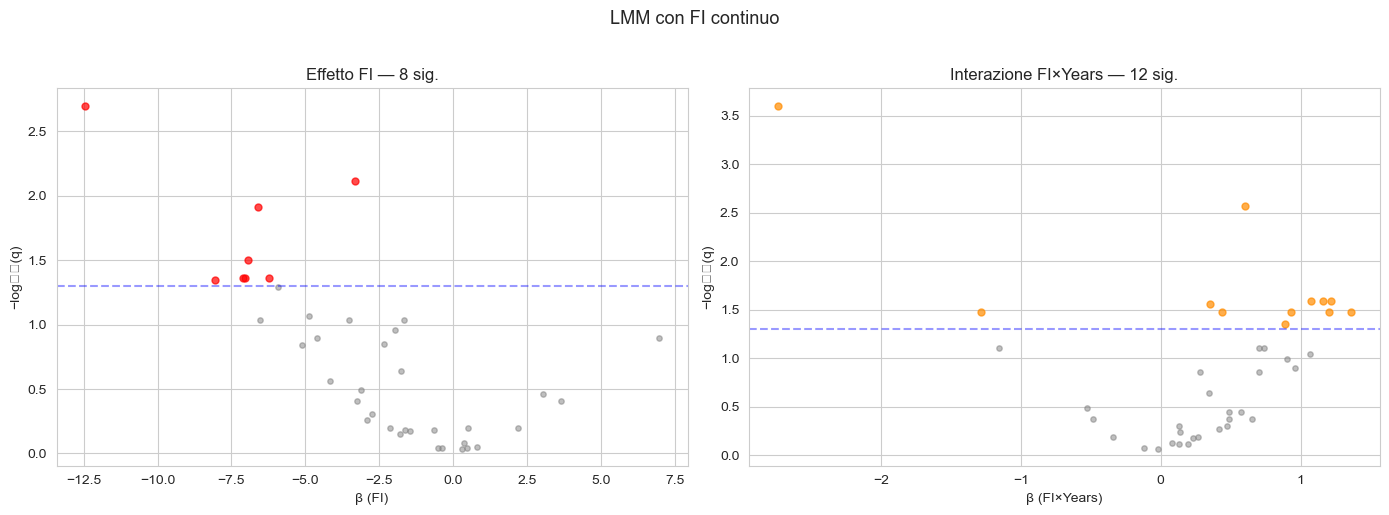

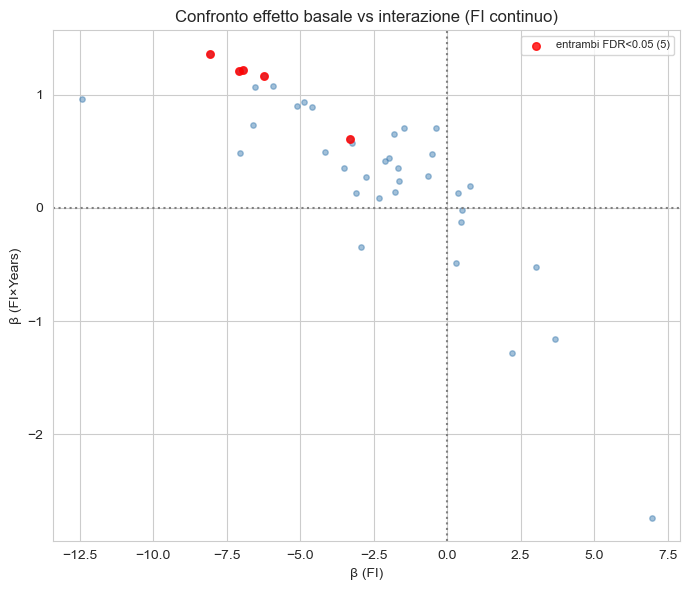


✓ Salvati: univariate_lmm_fi_continuous.csv, univariate_spearman_fi.csv


In [42]:
# ══════════════════════════════════════════════════════════════════════
# 11. UNIVARIATA — FI CONTINUO
# ══════════════════════════════════════════════════════════════════════

print("LMM: log₂(metabolita) ~ FI × Years + (1|Code)\n")

lmm_fi_rows = []
for m in mets_univ:
    dat = pd.DataFrame({
        "y": np.log2(df_master[m].clip(lower=1e-12).astype(float)),
        "fi": df_master["FI"].astype(float),
        "years": df_master["Years"].astype(float),
        "code": df_master["Code"]}).dropna()
    if dat["fi"].nunique() < 5 or dat["code"].nunique() < 5:
        continue
    try:
        fit = smf.mixedlm("y ~ fi * years", data=dat,
                           groups=dat["code"]).fit(reml=False, method="lbfgs")
        lmm_fi_rows.append({
            "metabolite": m,
            "beta_fi": fit.params.get("fi", np.nan),
            "p_fi": fit.pvalues.get("fi", np.nan),
            "beta_years": fit.params.get("years", np.nan),
            "p_years": fit.pvalues.get("years", np.nan),
            "beta_fi_years": fit.params.get("fi:years", np.nan),
            "p_fi_years": fit.pvalues.get("fi:years", np.nan)})
    except Exception:
        pass

lmm_fi_df = pd.DataFrame(lmm_fi_rows).sort_values("p_fi").reset_index(drop=True)
lmm_fi_df["q_fi"] = fdr_bh(lmm_fi_df["p_fi"].values)
lmm_fi_df["q_fi_years"] = fdr_bh(lmm_fi_df["p_fi_years"].values)
n_fi_sig = (lmm_fi_df["q_fi"] < 0.05).sum()
n_fix_sig = (lmm_fi_df["q_fi_years"] < 0.05).sum()
print(f"Effetto FI (FDR<0.05): {n_fi_sig}/{len(lmm_fi_df)}")
print(f"Interazione FI×Years (FDR<0.05): {n_fix_sig}/{len(lmm_fi_df)}")
display(lmm_fi_df.head(15)[
    ["metabolite", "beta_fi", "q_fi", "beta_fi_years", "q_fi_years"]].round(4))

# ── SPEARMAN CORRELATIONS PER TIMEPOINT ──────────────────────────────
print("\n" + "=" * 72)
print("Spearman: FI vs metabolita per timepoint")
print("=" * 72)

spear_rows = []
for m in mets_univ:
    row = {"metabolite": m}
    for t in TIMES:
        sub = df_master.loc[df_master["Time"] == t, ["FI", m]].dropna()
        if len(sub) >= 10:
            rho, p = spearmanr(sub["FI"], sub[m])
            row[f"rho_T{t}"] = rho
            row[f"p_T{t}"] = p
        else:
            row[f"rho_T{t}"] = np.nan
            row[f"p_T{t}"] = np.nan
    spear_rows.append(row)

spear_df = pd.DataFrame(spear_rows)
for t in TIMES:
    if spear_df[f"p_T{t}"].notna().any():
        spear_df[f"q_T{t}"] = fdr_bh(spear_df[f"p_T{t}"].values)
    else:
        spear_df[f"q_T{t}"] = np.nan
    n_s = int((spear_df[f"q_T{t}"] < 0.05).sum()) if spear_df[f"q_T{t}"].notna().any() else 0
    print(f"  T{t} (anno {TIME_TO_YEARS[t]}): {n_s}/{len(spear_df)} sig. (FDR<0.05)")

# ── VOLCANO PLOTS ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sig_fi = lmm_fi_df["q_fi"] < 0.05
xv = lmm_fi_df["beta_fi"].values
yv = -np.log10(lmm_fi_df["q_fi"].clip(lower=1e-50).values)
ax1.scatter(xv[~sig_fi], yv[~sig_fi], s=15, c="gray", alpha=0.5)
ax1.scatter(xv[sig_fi], yv[sig_fi], s=25, c="red", alpha=0.7)
ax1.axhline(-np.log10(0.05), ls="--", c="blue", alpha=0.4)
ax1.set_xlabel("β (FI)"); ax1.set_ylabel("−log₁₀(q)")
ax1.set_title(f"Effetto FI — {n_fi_sig} sig.")

sig_fix = lmm_fi_df["q_fi_years"] < 0.05
xv2 = lmm_fi_df["beta_fi_years"].values
yv2 = -np.log10(lmm_fi_df["q_fi_years"].clip(lower=1e-50).values)
ax2.scatter(xv2[~sig_fix], yv2[~sig_fix], s=15, c="gray", alpha=0.5)
ax2.scatter(xv2[sig_fix], yv2[sig_fix], s=25, c="darkorange", alpha=0.7)
ax2.axhline(-np.log10(0.05), ls="--", c="blue", alpha=0.4)
ax2.set_xlabel("β (FI×Years)"); ax2.set_ylabel("−log₁₀(q)")
ax2.set_title(f"Interazione FI×Years — {n_fix_sig} sig.")

plt.suptitle("LMM con FI continuo", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ── SCATTER BETA_FI vs BETA_INTERACTION ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(lmm_fi_df["beta_fi"], lmm_fi_df["beta_fi_years"],
           s=15, alpha=0.5, c="steelblue")
both = (lmm_fi_df["q_fi"] < 0.05) & (lmm_fi_df["q_fi_years"] < 0.05)
ax.scatter(lmm_fi_df.loc[both, "beta_fi"],
           lmm_fi_df.loc[both, "beta_fi_years"],
           s=30, c="red", alpha=0.8, label=f"entrambi FDR<0.05 ({both.sum()})")
ax.axhline(0, ls=":", c="gray"); ax.axvline(0, ls=":", c="gray")
ax.set_xlabel("β (FI)"); ax.set_ylabel("β (FI×Years)")
ax.set_title("Confronto effetto basale vs interazione (FI continuo)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# ── Salvataggio ──────────────────────────────────────────────────────
lmm_fi_df.to_csv(f"{OUTDIR}/univariate_lmm_fi_continuous.csv", index=False)
spear_df.to_csv(f"{OUTDIR}/univariate_spearman_fi.csv", index=False)
print(f"\n✓ Salvati: univariate_lmm_fi_continuous.csv, univariate_spearman_fi.csv")

## 12. Modello predittivo — FI a T4 dal profilo metabolomico

Il professore ha suggerito di verificare se la *pendenza* (slope) di un metabolita
lungo i primi 3 timepoint possa predire il valore del FI al timepoint finale:

$$\text{FI}_{T4} \;=\; \beta_0 + \beta_{\text{slope}}\,\text{slope}_m + \beta_{\text{FI}_1}\,\text{FI}_{T1} + \beta_{\text{Age}}\,\text{Age} + \varepsilon$$

- La **slope** di ogni metabolita è calcolata con una regressione lineare semplice
  log₂(metabolita) ~ Years sui timepoint T1–T3 per ogni soggetto.
- Un modello OLS per ogni metabolita, con R² e bootstrap 95% CI.
- Infine un **modello multiplo** con i top-k metaboliti.

Metaboliti con slope calcolata: 39
Soggetti con FI a T1 e T4: 609

Modelli stimati: 39
Slope significativa (FDR<0.05): 0/39


,metabolite,beta_slope,q_slope,R2_adj,R2_cv_mean
0,Resveratrol-O-glucuronide,-0.0066,0.0560,0.2867,0.2769
1,3-Methylhistidine; 1-Methylhistidine; 1-methyl...,-0.0070,0.0560,0.2860,0.2774
2,121512,-0.0061,0.1145,0.2836,0.2733
3,88195,-0.0069,0.1145,0.2830,0.2733
4,Phloretin,-0.0058,0.1453,0.2819,0.2659
5,Caffeine,-0.0033,0.1453,0.2816,0.2702
6,70569,-0.0061,0.1453,0.2813,0.2713
7,Saccharin,0.0052,0.2114,0.2803,0.2696
8,Uric acid,-0.0140,0.2454,0.2798,0.2691
9,Isorhamnetin,0.0076,0.3253,0.2790,0.2670


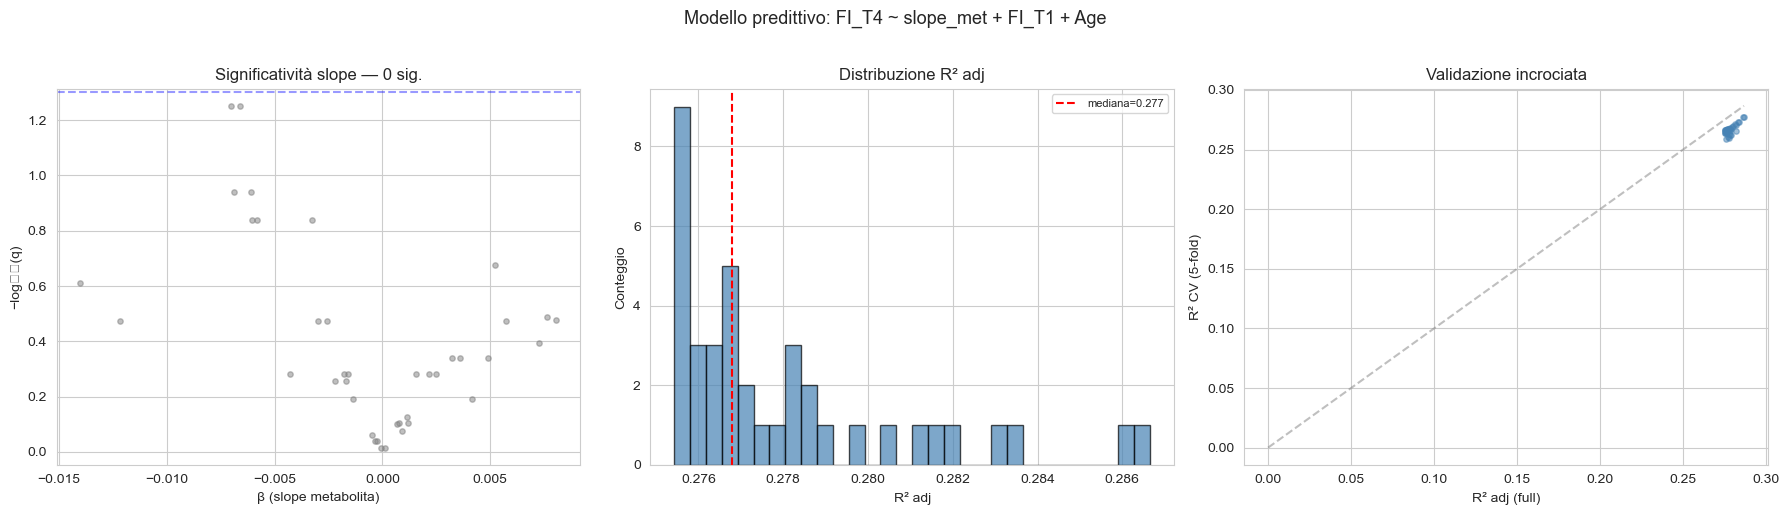

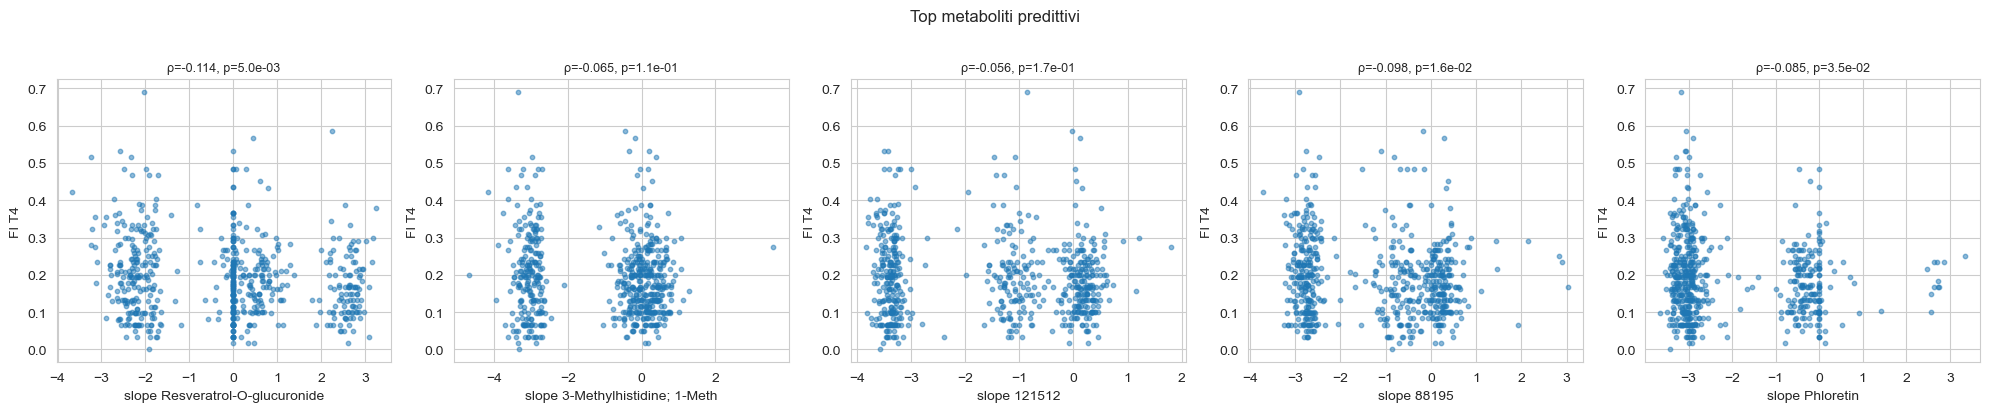


✓ Salvato: predictive_fi_t4.csv


In [43]:
# ══════════════════════════════════════════════════════════════════════
# 12. MODELLO PREDITTIVO — FI_T4 ~ slope_met + FI_T1 + Age
# ══════════════════════════════════════════════════════════════════════
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# ── 1. Calcolo slope individuale (T1–T3) ────────────────────────────
# Per ogni soggetto e metabolita: regressione lineare log₂(met) ~ Years
# sui primi 3 timepoint
t1_t3 = df_master[df_master["Time"].isin(TIMES[:3])].copy()
slopes_dict = {}
for m in mets_univ:
    s_list = []
    for code, g in t1_t3.groupby("Code"):
        sub = g[["Years", m]].dropna()
        if len(sub) >= 2:
            x = sub["Years"].values.reshape(-1, 1)
            y = np.log2(sub[m].clip(lower=1e-12).astype(float).values)
            lr = LinearRegression().fit(x, y)
            s_list.append({"Code": code, f"slope_{m}": lr.coef_[0]})
    if s_list:
        slopes_dict[m] = pd.DataFrame(s_list)

print(f"Metaboliti con slope calcolata: {len(slopes_dict)}")

# ── 2. Costruzione dataset predittivo ────────────────────────────────
# FI al T4 come target
t4 = df_master[df_master["Time"] == TIMES[-1]][["Code", "FI"]].dropna()
t4 = t4.rename(columns={"FI": "FI_T4"})

# FI al T1 come covariate
t1 = df_master[df_master["Time"] == TIMES[0]][["Code", "FI", "Age"]].dropna()
t1 = t1.rename(columns={"FI": "FI_T1"})

base = t4.merge(t1, on="Code", how="inner")
print(f"Soggetti con FI a T1 e T4: {len(base)}")

# ── 3. Modello univariato per ogni metabolita ────────────────────────
pred_rows = []
for m, sl_df in slopes_dict.items():
    dat = base.merge(sl_df, on="Code", how="inner")
    sc = f"slope_{m}"
    if len(dat) < 20 or dat[sc].std() == 0:
        continue
    X = dat[["FI_T1", "Age", sc]].values
    y = dat["FI_T4"].values
    try:
        # OLS with cross-validation (5-fold)
        scaler = StandardScaler()
        X_s = scaler.fit_transform(X)
        cv_r2 = cross_val_score(LinearRegression(), X_s, y, cv=5,
                                 scoring="r2")
        # Full-model OLS for coefficients
        import statsmodels.api as sm
        X_ols = sm.add_constant(dat[["FI_T1", "Age", sc]])
        ols = sm.OLS(y, X_ols).fit()
        pred_rows.append({
            "metabolite": m,
            "beta_slope": ols.params.get(sc, np.nan),
            "p_slope": ols.pvalues.get(sc, np.nan),
            "beta_FI_T1": ols.params.get("FI_T1", np.nan),
            "p_FI_T1": ols.pvalues.get("FI_T1", np.nan),
            "beta_Age": ols.params.get("Age", np.nan),
            "p_Age": ols.pvalues.get("Age", np.nan),
            "R2_adj": ols.rsquared_adj,
            "R2_cv_mean": cv_r2.mean(),
            "R2_cv_std": cv_r2.std(),
            "n": len(dat)})
    except Exception:
        pass

pred_df = pd.DataFrame(pred_rows).sort_values("p_slope").reset_index(drop=True)
pred_df["q_slope"] = fdr_bh(pred_df["p_slope"].values)
n_pred_sig = (pred_df["q_slope"] < 0.05).sum()
print(f"\nModelli stimati: {len(pred_df)}")
print(f"Slope significativa (FDR<0.05): {n_pred_sig}/{len(pred_df)}")
display(pred_df.head(15)[
    ["metabolite", "beta_slope", "q_slope", "R2_adj", "R2_cv_mean"]].round(4))

# ── 4. Visualizzazioni ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) Volcano: p_slope
sig_s = pred_df["q_slope"] < 0.05
xv = pred_df["beta_slope"].values
yv = -np.log10(pred_df["q_slope"].clip(lower=1e-50).values)
axes[0].scatter(xv[~sig_s], yv[~sig_s], s=15, c="gray", alpha=0.5)
axes[0].scatter(xv[sig_s], yv[sig_s], s=25, c="red", alpha=0.7)
axes[0].axhline(-np.log10(0.05), ls="--", c="blue", alpha=0.4)
axes[0].set_xlabel("β (slope metabolita)")
axes[0].set_ylabel("−log₁₀(q)")
axes[0].set_title(f"Significatività slope — {n_pred_sig} sig.")

# b) R² adj distribution
axes[1].hist(pred_df["R2_adj"], bins=30, edgecolor="k", alpha=0.7,
             color="steelblue")
axes[1].axvline(pred_df["R2_adj"].median(), ls="--", c="red",
                label=f"mediana={pred_df['R2_adj'].median():.3f}")
axes[1].set_xlabel("R² adj"); axes[1].set_ylabel("Conteggio")
axes[1].set_title("Distribuzione R² adj"); axes[1].legend(fontsize=8)

# c) R² cv vs R² adj
axes[2].scatter(pred_df["R2_adj"], pred_df["R2_cv_mean"],
                s=15, alpha=0.5, c="steelblue")
axes[2].plot([0, pred_df["R2_adj"].max()], [0, pred_df["R2_adj"].max()],
             ls="--", c="gray", alpha=0.5)
axes[2].set_xlabel("R² adj (full)"); axes[2].set_ylabel("R² CV (5-fold)")
axes[2].set_title("Validazione incrociata")

plt.suptitle("Modello predittivo: FI_T4 ~ slope_met + FI_T1 + Age",
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ── 5. Top metaboliti: scatter FI_T4 vs slope ────────────────────────
top5_pred = pred_df.head(5)["metabolite"].tolist()
if top5_pred:
    fig, axes = plt.subplots(1, min(5, len(top5_pred)),
                              figsize=(4 * min(5, len(top5_pred)), 4))
    if len(top5_pred) == 1:
        axes = [axes]
    for ax, m in zip(axes, top5_pred):
        sl_df = slopes_dict[m]
        dat = base.merge(sl_df, on="Code", how="inner")
        ax.scatter(dat[f"slope_{m}"], dat["FI_T4"], s=10, alpha=0.5)
        rho, p = spearmanr(dat[f"slope_{m}"], dat["FI_T4"])
        ax.set_xlabel(f"slope {m[:25]}")
        ax.set_ylabel("FI T4")
        ax.set_title(f"ρ={rho:.3f}, p={p:.1e}", fontsize=9)
    plt.suptitle("Top metaboliti predittivi", fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()

# ── Salvataggio ──────────────────────────────────────────────────────
pred_df.to_csv(f"{OUTDIR}/predictive_fi_t4.csv", index=False)
print(f"\n✓ Salvato: predictive_fi_t4.csv")

## 13. Riepilogo delle modifiche e scelte metodologiche

### Cosa è cambiato rispetto alla versione precedente

| Aspetto | Prima | Ora |
|---|---|---|
| Modello longitudinale | GEE (convergenza instabile, matrice singolare) | **LMM** via `mixedlm` con ottimizzatore LBFGS |
| Soglia floor effect | 4 soglie separate | Unica `FLOOR_THR = 40 %` |
| Sezioni ridondanti | Missingness dettagliata, distribuzioni, ICC, drift, normalizzazione | Rimosse — QC compattato in §3 |
| Confronto età | Assente | §8: Mann-Whitney + boxplot + scatter |
| Analisi NF longitudinale | Assente | §9: Friedman per ripetute sui Never-frail |
| MW per timepoint | Usava la variabile "Group" (Ever-frail) | Usa **stato frail attuale** a ogni visita |
| FI continuo | Assente | §11: LMM con FI continuo + Spearman per timepoint |
| Modello predittivo | Assente | §12: OLS con slope metabolita + FI_T1 + Age → FI_T4 |

### Scelte metodologiche

1. **LMM vs GEE**: il LMM con intercetta random per soggetto è più
   stabile quando la matrice di correlazione è mal-condizionata; l'ottimizzatore
   LBFGS migliora ulteriormente la convergenza.
2. **Floor effect a 40 %**: soglia conservativa; l'analisi di sensibilità (§3)
   mostra il trade-off tra metaboliti inclusi e rischio di floor.
3. **Stato frail attuale per MW**: più informativo del semplice "ever-frail"
   perché cattura la transizione dinamica e tiene conto del fatto che a T1
   nessun soggetto è frail.
4. **Friedman test (§9)**: test non-parametrico per misure ripetute adatto
   a verificare se i metaboliti variano nel tempo nei soggetti sani.
5. **Modello predittivo (§12)**: analisi esplorativa della capacità delle
   traiettorie metabolomiche di predire il FI futuro, validata con 5-fold CV.

### Limitazioni

- Il **campione** è relativamente piccolo per analisi multivariate su 193 metaboliti.
- La **correzione FDR** è conservativa; risultati borderline meritano attenzione.
- Il **modello predittivo** è esplorativo e non sostituisce una validazione esterna.
- La **slope** è calcolata su 3 timepoint (minimo per una regressione lineare).